---
## Step 0: Inventory local result files

This section scans `/Users/julianreynolds/Project/data/Results` and builds a per-file inventory: folder, file name, type, size, row count, number of columns, and the first five column names. Parquet files are inspected from metadata only, so the large prediction files are not loaded into memory. CSV files are counted by streaming line by line.


In [ ]:
# ====================================================
# Inventory local model result files without loading big datasets
# ====================================================
from pathlib import Path
import csv
import importlib.util
import json
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "pyarrow": "pyarrow",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import pandas as pd
import pyarrow.parquet as pq

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda iterable, **_: iterable

RESULTS_DIR = Path("/Users/julianreynolds/Project/data/Results")
COLUMN_NAME_SEPARATOR = " | "
MAX_JSON_PARSE_BYTES = 100 * 1024 * 1024
GENERATED_INVENTORY_FILES = {"results_inventory.csv", "test_set_results_inventory.csv"}
# The stock-level OOS test set has exactly this many rows.
# We use it to keep only full test-set prediction files and exclude manifests,
# diagnostics, summaries, yearly split files, and other auxiliary outputs.
TEST_SET_ROW_COUNT = 2_136_916


def bytes_to_mb(n_bytes):
    return round(n_bytes / (1024 ** 2), 3)


def relative_folder(path):
    relative_parent = path.parent.relative_to(RESULTS_DIR)
    return "." if str(relative_parent) == "." else relative_parent.as_posix()


def column_text(columns):
    if not columns:
        return ""
    return COLUMN_NAME_SEPARATOR.join(str(column) for column in columns)


def first_columns_text(columns, n=5):
    if not columns:
        return ""
    return COLUMN_NAME_SEPARATOR.join(str(column) for column in columns[:n])


def detail_from_columns(columns, rows, row_groups=pd.NA, inspection_method="", notes=""):
    return {
        "rows": rows,
        "n_columns": len(columns),
        "first_5_columns": first_columns_text(columns),
        "columns": column_text(columns),
        "row_groups": row_groups,
        "inspection_method": inspection_method,
        "notes": notes,
    }


def inspect_parquet(path):
    parquet_file = pq.ParquetFile(path)
    metadata = parquet_file.metadata
    columns = list(parquet_file.schema_arrow.names)
    return detail_from_columns(
        columns=columns,
        rows=metadata.num_rows,
        row_groups=metadata.num_row_groups,
        inspection_method="parquet metadata only",
    )


def inspect_csv(path):
    last_error = None
    for encoding in ("utf-8-sig", "utf-8", "latin-1"):
        try:
            with path.open("r", encoding=encoding, newline="") as handle:
                sample = handle.read(65536)
                handle.seek(0)
                try:
                    dialect = csv.Sniffer().sniff(sample, delimiters=",;\t|")
                except csv.Error:
                    dialect = csv.excel
                reader = csv.reader(handle, dialect)
                header = next(reader, [])
                rows = sum(1 for _ in reader)

            return detail_from_columns(
                columns=header,
                rows=rows,
                inspection_method="csv header + streamed row count",
                notes=f"encoding={encoding}; delimiter={repr(dialect.delimiter)}",
            )
        except UnicodeDecodeError as error:
            last_error = error

    raise UnicodeDecodeError(
        "csv",
        b"",
        0,
        1,
        f"could not decode with utf-8-sig, utf-8, or latin-1: {last_error}",
    )


def inspect_json(path):
    if path.stat().st_size > MAX_JSON_PARSE_BYTES:
        return {
            "rows": pd.NA,
            "n_columns": pd.NA,
            "first_5_columns": "",
            "columns": "",
            "row_groups": pd.NA,
            "inspection_method": "json size only",
            "notes": f"skipped parse because file exceeds {bytes_to_mb(MAX_JSON_PARSE_BYTES)} MB",
        }

    with path.open("r", encoding="utf-8") as handle:
        data = json.load(handle)

    if isinstance(data, list):
        columns = sorted({key for row in data if isinstance(row, dict) for key in row.keys()})
        rows = len(data)
        note = "top-level JSON list"
    elif isinstance(data, dict):
        columns = list(data.keys())
        rows = 1
        note = "top-level JSON object"
    else:
        columns = []
        rows = 1
        note = f"top-level JSON {type(data).__name__}"

    return detail_from_columns(
        columns=columns,
        rows=rows,
        inspection_method="json parsed",
        notes=note,
    )


def inspect_result_file(path):
    stat = path.stat()
    suffix = path.suffix.lower().lstrip(".") or "unknown"
    base_record = {
        "folder": relative_folder(path),
        "file name": path.name,
        "relative_path": path.relative_to(RESULTS_DIR).as_posix(),
        "file_type": suffix,
        "size_mb": bytes_to_mb(stat.st_size),
        "modified_time": pd.Timestamp(stat.st_mtime, unit="s"),
    }

    try:
        if suffix == "parquet":
            detail = inspect_parquet(path)
        elif suffix == "csv":
            detail = inspect_csv(path)
        elif suffix == "json":
            detail = inspect_json(path)
        else:
            detail = {
                "rows": pd.NA,
                "n_columns": pd.NA,
                "first_5_columns": "",
                "columns": "",
                "row_groups": pd.NA,
                "inspection_method": "size only",
                "notes": "unsupported file type",
            }
    except Exception as error:
        detail = {
            "rows": pd.NA,
            "n_columns": pd.NA,
            "first_5_columns": "",
            "columns": "",
            "row_groups": pd.NA,
            "inspection_method": "failed",
            "notes": repr(error),
        }

    return {**base_record, **detail}


if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found: {RESULTS_DIR}")

result_files = sorted(
    path
    for path in RESULTS_DIR.rglob("*")
    if path.is_file()
    and path.name not in GENERATED_INVENTORY_FILES
    and not path.name.startswith(".")
    and not path.name.startswith("._")
    and not path.name.endswith(".download")
)

records = [inspect_result_file(path) for path in tqdm(result_files, desc="Scanning result files")]
results_inventory = pd.DataFrame(records).sort_values(["folder", "file name"]).reset_index(drop=True)
# Keep only full stock-level test-set prediction files.
# These are the files with exactly 2,136,916 rows, matching the OOS test-set size.
# Smaller files are diagnostics/summaries/yearly chunks; larger combined files contain
# multiple model outputs stacked together, so they are not the individual datasets
# we want for the portfolio comparison input check.
test_set_inventory = (
    results_inventory
    .assign(rows_numeric=pd.to_numeric(results_inventory["rows"], errors="coerce"))
    .query("rows_numeric == @TEST_SET_ROW_COUNT")
    .drop(columns="rows_numeric")
    .reset_index(drop=True)
)
folder_inventory = (
    test_set_inventory
    .assign(rows_numeric=pd.to_numeric(test_set_inventory["rows"], errors="coerce"))
    .groupby("folder", dropna=False)
    .agg(
        total_size_mb=("size_mb", "sum"),
        test_set_rows=("rows_numeric", "sum"),
    )
    .reset_index()
)
folder_inventory["total_size_mb"] = folder_inventory["total_size_mb"].round(3)
folder_inventory["test_set_rows"] = folder_inventory["test_set_rows"].astype("Int64")

per_file_inventory = test_set_inventory[[
    "folder",
    "file name",
    "file_type",
    "size_mb",
    "rows",
    "n_columns",
    "first_5_columns",
    "inspection_method",
    "notes",
]]

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 180)

print(f"Scanned {len(results_inventory)} files from {RESULTS_DIR}")
print(f"Found {len(test_set_inventory)} files with {TEST_SET_ROW_COUNT:,} rows")
display(folder_inventory)
display(per_file_inventory)


---
## Step 0A: Inspect full columns for test-set files

This view keeps only the files with the full OOS test-set row count and displays each file name with its complete column list.


In [ ]:
# ====================================================
# Show full column lists for the test-set files
# ====================================================
# This relies on the inventory cell above. It does not reload any large datasets;
# parquet columns come from metadata and CSV columns come from the header scan.
test_set_columns_view = (
    test_set_inventory[["file name", "columns"]]
    .sort_values("file name")
    .reset_index(drop=True)
)

display(test_set_columns_view)


---
## Step 1: Normalize all model predictions into one portfolio-ready stock panel

The portfolio code needs every model in the same bottom-up stock-level shape: one row per `(model, permno, date)` with a forecast, realized excess return, market equity, exchange code, sort characteristics, and lagged market equity for ex ante value weights.

The downloaded result files do not all contain the same information, so this section standardizes them carefully:

- **FML / OLS / ENet files** already have `permno`, `date`, and model forecasts, but they do not carry realized returns or the portfolio sort characteristics. We join them to `gkx2020_panel_trimmed.parquet` by `permno,date` to recover `ret_excess`, `me`, `exchcd`, `bm`, `agr`, `operprof`, and `mom12m`.
- **GLM** already has stock identifiers plus `ret_excess`, `me`, `exchcd`, and forecasts, but it is still missing the sort characteristics used for HML/CMA/RMW/UMD. We use the same panel join so every model uses one canonical source for portfolio characteristics.
- **PCR and PLS** store their forecast as `pred` and include identifiers, returns, exchange code, and market equity. We rename `pred` to `prediction` and join the panel for the missing sort characteristics.
- **RF and GBRT** store `permno`, `date`, `actual`, and `predicted`. We rename `predicted` to `prediction` and join the panel for market equity, exchange code, realized return, and characteristics.
- **NN1/NN3/NN5** only store `test_year`, `actual`, and `predicted`. Because they were saved in the same annual OOS test-row order used during training, we reconstruct `permno`, `date`, and all portfolio identity columns from the GKX panel using the original 1987-2021 annual test ordering, then attach the NN forecasts row by row.
- **`TEST_recursive_predictions.parquet`** is not loaded by default because it duplicates RF and GBRT in one combined tree file; using it together with `RF_predictions.parquet` and `GBRT_predictions.parquet` would double count those models.

Finally, we compute `weight_me` from `Monthly_returns_crsp.csv` as prior-month market equity. That is needed because portfolios must be weighted using information known before the forecast-month return is realized.


In [4]:
# ====================================================
# Normalize all model prediction files for portfolio analysis
# ====================================================
from pathlib import Path
import gc
import importlib.util
import subprocess
import sys
import warnings

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "pyarrow": "pyarrow",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

# Keep this notebook self-contained. If a previous cell defined SMOKE_TEST, respect it;
# otherwise default to the full 1987-2021 OOS period used by the downloaded files.
SMOKE_TEST = globals().get("SMOKE_TEST", False)
PORTFOLIO_FORECAST_MODE = "smoke" if SMOKE_TEST else "full"
PORTFOLIO_MARKET_TOP_N = 500
SAVE_PORTFOLIO_MEMBERSHIP = PORTFOLIO_FORECAST_MODE == "smoke"
SMB_INCLUDE_MOMENTUM_SORT = False
SAVE_NORMALIZED_STOCK_PREDICTIONS = False

PROJECT_ROOT = Path("/Users/julianreynolds/Project")
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = DATA_DIR / "Results"
PANEL_PATH = DATA_DIR / "gkx2020_panel_trimmed.parquet"
CRSP_MONTHLY_PATH = DATA_DIR / "Monthly_returns_crsp.csv"
output_dir = PROJECT_ROOT / "output" / "portfolio_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

TEST_YEARS = list(range(1987, 2022))
TEST_SET_ROW_COUNT = 2_136_916
PORTFOLIO_SORT_CHARACTERISTICS = ["bm", "agr", "operprof", "mom12m"]
PANEL_REFERENCE_COLUMNS = [
    "permno",
    "date",
    "ret_excess",
    "me",
    "exchcd",
    *PORTFOLIO_SORT_CHARACTERISTICS,
]
PORTFOLIO_REQUIRED_COLUMNS = [
    "model",
    "permno",
    "date",
    "prediction",
    "ret_excess",
    "me",
    "exchcd",
    "weight_me",
    *PORTFOLIO_SORT_CHARACTERISTICS,
]

# Each entry says how to turn one downloaded result file into the common schema.
# keyed = file already has permno/date, so we can join the GKX panel by those keys.
# row_order = file lacks permno/date, so we attach the GKX panel's annual OOS rows by order.
PREDICTION_FILE_SPECS = [
    {
        "model": "OLS-3",
        "folder": "fml_ols_enet_results",
        "file_name": "FML_OLS_ENet_fixed_ols3_recursive_oos_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": None,
        "why": "FML OLS-3 has stock keys and forecasts only; panel join supplies realized returns and portfolio characteristics.",
    },
    {
        "model": "OLS-Full",
        "folder": "fml_ols_enet_results",
        "file_name": "FML_OLS_ENet_fixed_ols_full_recursive_oos_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": None,
        "why": "FML full OLS has stock keys and forecasts only; panel join supplies realized returns and portfolio characteristics.",
    },
    {
        "model": "ENet",
        "folder": "fml_ols_enet_results",
        "file_name": "FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": None,
        "why": "Elastic Net has stock keys and forecasts; alpha/l1 metadata is retained only in the source file, while portfolio inputs come from the panel join.",
    },
    {
        "model": "ENet-H",
        "folder": "fml_ols_enet_results",
        "file_name": "FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": None,
        "why": "Huber Elastic Net has stock keys and forecasts; panel join adds realized returns, exchange code, market equity, and sort characteristics.",
    },
    {
        "model": "GLM",
        "folder": "glm_3",
        "file_name": "glm_3_stock_level_oos_predictions_with_ids.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": "actual",
        "why": "GLM already has identifiers, actuals, returns, exchange code, and market equity; panel join adds the missing sort characteristics and keeps definitions consistent.",
    },
    {
        "model": "PCR",
        "folder": "pcr_pls",
        "file_name": "pcr_predictions.csv",
        "loader": "keyed",
        "prediction_col": "pred",
        "actual_col": "ret_excess",
        "why": "PCR stores forecasts as pred and already has stock keys; rename pred to prediction and join panel for sort characteristics.",
    },
    {
        "model": "PLS",
        "folder": "pcr_pls",
        "file_name": "pls_predictions.csv",
        "loader": "keyed",
        "prediction_col": "pred",
        "actual_col": "ret_excess",
        "why": "PLS stores forecasts as pred and already has stock keys; rename pred to prediction and join panel for sort characteristics.",
    },
    {
        "model": "RF",
        "folder": "tree_results",
        "file_name": "RF_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "RF stores only identifiers, actual, and predicted; panel join adds returns, market equity, exchange code, and sort characteristics.",
    },
    {
        "model": "GBRT",
        "folder": "tree_results",
        "file_name": "GBRT_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "GBRT stores only identifiers, actual, and predicted; panel join adds returns, market equity, exchange code, and sort characteristics.",
    },
    {
        "model": "NN1",
        "folder": "nn_results",
        "file_name": "NN1_predictions.parquet",
        "loader": "row_order",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "NN1 lacks permno/date, so we reconstruct stock identity from the panel using the same annual OOS row order used by training.",
    },
    {
        "model": "NN3",
        "folder": "nn_results",
        "file_name": "NN3_predictions.parquet",
        "loader": "row_order",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "NN3 lacks permno/date, so we reconstruct stock identity from the panel using the same annual OOS row order used by training.",
    },
    {
        "model": "NN5",
        "folder": "nn_results",
        "file_name": "NN5_predictions.parquet",
        "loader": "row_order",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "NN5 lacks permno/date, so we reconstruct stock identity from the panel using the same annual OOS row order used by training.",
    },
]

EXCLUDED_FULL_TEST_SET_FILES = pd.DataFrame([
    {
        "folder": "tree_results",
        "file name": "TEST_recursive_predictions.parquet",
        "reason": "Contains RF and GBRT together. Excluded to avoid double counting because RF_predictions.parquet and GBRT_predictions.parquet are loaded separately.",
    }
])


def normalize_prediction_date(series: pd.Series) -> pd.Series:
    """Normalize all dates to month-start timestamps so files and panel join cleanly."""
    return pd.to_datetime(series).dt.to_period("M").dt.to_timestamp()


def read_prediction_file(path: Path) -> pd.DataFrame:
    """Read parquet or CSV prediction files using the extension only."""
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported prediction file type: {path}")


def compact_list(values) -> str:
    return ", ".join(str(value) for value in values)


def missing_from_input(input_columns, needed_columns) -> str:
    missing = [column for column in needed_columns if column not in input_columns]
    return compact_list(missing) if missing else "none"


def build_oos_panel_reference(panel_path: Path) -> pd.DataFrame:
    """Load only the columns needed to enrich predictions and reconstruct NN rows."""
    if not panel_path.exists():
        raise FileNotFoundError(f"Missing GKX panel: {panel_path}")

    panel = pd.read_parquet(panel_path, columns=PANEL_REFERENCE_COLUMNS)
    panel["date"] = normalize_prediction_date(panel["date"])
    panel["test_year"] = panel["date"].dt.year.astype("int16")

    annual_frames = []
    for year in TEST_YEARS:
        annual = panel.loc[panel["test_year"] == year].copy()
        if annual.empty:
            raise ValueError(f"No panel rows found for test year {year}.")
        annual_frames.append(annual)

    oos_panel = pd.concat(annual_frames, ignore_index=True)
    if len(oos_panel) != TEST_SET_ROW_COUNT:
        raise ValueError(
            f"Expected {TEST_SET_ROW_COUNT:,} OOS panel rows, found {len(oos_panel):,}. "
            "The row-order NN reconstruction would be unsafe."
        )

    duplicate_keys = oos_panel.duplicated(["permno", "date"]).sum()
    if duplicate_keys:
        raise ValueError(f"Panel has {duplicate_keys:,} duplicate permno/date rows in the OOS period.")

    for column in ["ret_excess", "me", *PORTFOLIO_SORT_CHARACTERISTICS]:
        oos_panel[column] = pd.to_numeric(oos_panel[column], errors="coerce").astype("float32")
    oos_panel["permno"] = pd.to_numeric(oos_panel["permno"], errors="raise").astype("int64")
    oos_panel["exchcd"] = pd.to_numeric(oos_panel["exchcd"], errors="coerce").astype("float32")
    return oos_panel


def attach_panel_by_key(pred_df: pd.DataFrame, spec: dict, panel_reference: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Normalize a file that already has permno/date keys, then enrich from the panel."""
    path = RESULTS_DIR / spec["folder"] / spec["file_name"]
    input_columns = list(pred_df.columns)
    required_input = ["permno", "date", spec["prediction_col"]]
    if spec["actual_col"] is not None:
        required_input.append(spec["actual_col"])
    missing_input = [column for column in required_input if column not in pred_df.columns]
    if missing_input:
        raise ValueError(f"{path.name} is missing required input columns: {missing_input}")

    working = pd.DataFrame({
        "permno": pd.to_numeric(pred_df["permno"], errors="raise").astype("int64"),
        "date": normalize_prediction_date(pred_df["date"]),
        "prediction": pd.to_numeric(pred_df[spec["prediction_col"]], errors="coerce").astype("float32"),
    })
    if spec["actual_col"] is not None:
        working["actual"] = pd.to_numeric(pred_df[spec["actual_col"]], errors="coerce").astype("float32")

    merged = working.merge(
        panel_reference,
        on=["permno", "date"],
        how="left",
        validate="many_to_one",
        indicator=True,
    )
    missing_panel_rows = int((merged["_merge"] != "both").sum())
    merged = merged.drop(columns="_merge")

    if "actual" not in merged.columns:
        merged["actual"] = merged["ret_excess"]
        actual_source = "panel ret_excess"
        max_actual_gap = 0.0
    else:
        actual_source = spec["actual_col"]
        actual_gap = (merged["actual"].astype("float64") - merged["ret_excess"].astype("float64")).abs()
        max_actual_gap = float(actual_gap.max(skipna=True))

    merged.insert(0, "model", spec["model"])
    merged["source_folder"] = spec["folder"]
    merged["source_file"] = spec["file_name"]

    audit = {
        "model": spec["model"],
        "source_file": spec["file_name"],
        "loader": "permno/date panel join",
        "input_rows": len(pred_df),
        "output_rows": len(merged),
        "prediction_column_used": spec["prediction_col"],
        "actual_source": actual_source,
        "missing_input_before_enrichment": missing_from_input(
            input_columns,
            ["permno", "date", "prediction", "ret_excess", "me", "exchcd", *PORTFOLIO_SORT_CHARACTERISTICS, "weight_me"],
        ),
        "missing_panel_rows": missing_panel_rows,
        "max_actual_vs_panel_ret_excess_gap": max_actual_gap,
        "normalization_note": spec["why"],
    }
    return merged, audit


def attach_panel_by_row_order(pred_df: pd.DataFrame, spec: dict, oos_identity: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Normalize an NN file by attaching the canonical OOS panel rows by saved row order."""
    input_columns = list(pred_df.columns)
    path = RESULTS_DIR / spec["folder"] / spec["file_name"]
    required_input = ["test_year", spec["prediction_col"], spec["actual_col"]]
    missing_input = [column for column in required_input if column not in pred_df.columns]
    if missing_input:
        raise ValueError(f"{path.name} is missing required input columns: {missing_input}")
    if len(pred_df) != len(oos_identity):
        raise ValueError(
            f"{path.name}: prediction rows ({len(pred_df):,}) do not match "
            f"OOS identity rows ({len(oos_identity):,})."
        )

    frame = oos_identity.copy()
    nn_test_year = pd.to_numeric(pred_df["test_year"], errors="raise").astype("int16")
    test_year_mismatches = int((nn_test_year.to_numpy() != frame["test_year"].to_numpy()).sum())
    if test_year_mismatches:
        raise ValueError(
            f"{path.name}: {test_year_mismatches:,} test_year rows do not match the panel OOS ordering."
        )

    frame.insert(0, "model", spec["model"])
    frame["prediction"] = pd.to_numeric(pred_df[spec["prediction_col"]], errors="coerce").astype("float32")
    frame["actual"] = pd.to_numeric(pred_df[spec["actual_col"]], errors="coerce").astype("float32")
    frame["source_folder"] = spec["folder"]
    frame["source_file"] = spec["file_name"]

    actual_gap = (frame["actual"].astype("float64") - frame["ret_excess"].astype("float64")).abs()
    audit = {
        "model": spec["model"],
        "source_file": spec["file_name"],
        "loader": "annual OOS row-order reconstruction",
        "input_rows": len(pred_df),
        "output_rows": len(frame),
        "prediction_column_used": spec["prediction_col"],
        "actual_source": spec["actual_col"],
        "missing_input_before_enrichment": missing_from_input(
            input_columns,
            ["permno", "date", "prediction", "ret_excess", "me", "exchcd", *PORTFOLIO_SORT_CHARACTERISTICS, "weight_me"],
        ),
        "missing_panel_rows": 0,
        "max_actual_vs_panel_ret_excess_gap": float(actual_gap.max(skipna=True)),
        "normalization_note": spec["why"],
    }
    return frame, audit


def add_ex_ante_market_equity(stock_predictions: pd.DataFrame, crsp_path: Path) -> pd.DataFrame:
    """Attach prior-month market equity for ex ante portfolio weights."""
    if not crsp_path.exists():
        raise FileNotFoundError(f"Missing CRSP monthly file: {crsp_path}")

    crsp_me = pd.read_csv(crsp_path, usecols=["permno", "date", "me"])
    crsp_me["permno"] = pd.to_numeric(crsp_me["permno"], errors="raise").astype("int64")
    crsp_me["forecast_month"] = pd.to_datetime(crsp_me["date"]).dt.to_period("M")
    crsp_me["me"] = pd.to_numeric(crsp_me["me"], errors="coerce").astype("float32")
    crsp_me = crsp_me.sort_values(["permno", "forecast_month"])
    crsp_me["weight_me"] = crsp_me.groupby("permno", sort=False)["me"].shift(1).astype("float32")
    crsp_me = crsp_me[["permno", "forecast_month", "weight_me"]]

    out = stock_predictions.copy()
    out["forecast_month"] = pd.to_datetime(out["date"]).dt.to_period("M")
    out = out.merge(
        crsp_me,
        on=["permno", "forecast_month"],
        how="left",
        validate="many_to_one",
    )
    out = out.drop(columns="forecast_month")
    return out


def finalize_stock_prediction_dtypes(stock_predictions: pd.DataFrame) -> pd.DataFrame:
    """Reduce memory and enforce numeric columns before portfolio construction."""
    out = stock_predictions.copy()
    out["model"] = out["model"].astype("category")
    out["source_folder"] = out["source_folder"].astype("category")
    out["source_file"] = out["source_file"].astype("category")
    out["permno"] = pd.to_numeric(out["permno"], errors="raise").astype("int64")
    out["date"] = normalize_prediction_date(out["date"])
    out["test_year"] = pd.to_numeric(out["test_year"], errors="coerce").astype("int16")
    out["exchcd"] = pd.to_numeric(out["exchcd"], errors="coerce").astype("float32")
    for column in ["prediction", "actual", "ret_excess", "me", "weight_me", *PORTFOLIO_SORT_CHARACTERISTICS]:
        out[column] = pd.to_numeric(out[column], errors="coerce").astype("float32")
    return out.sort_values(["model", "date", "permno"]).reset_index(drop=True)


def build_all_model_stock_predictions() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load, standardize, enrich, and audit every portfolio-relevant model file."""
    oos_panel_reference = build_oos_panel_reference(PANEL_PATH)

    frames = []
    audit_rows = []
    for spec in PREDICTION_FILE_SPECS:
        path = RESULTS_DIR / spec["folder"] / spec["file_name"]
        if not path.exists():
            raise FileNotFoundError(f"Missing prediction file for {spec['model']}: {path}")

        pred_df = read_prediction_file(path)
        if len(pred_df) != TEST_SET_ROW_COUNT:
            raise ValueError(
                f"{path.name}: expected {TEST_SET_ROW_COUNT:,} rows, found {len(pred_df):,}."
            )

        if spec["loader"] == "keyed":
            frame, audit = attach_panel_by_key(pred_df, spec, oos_panel_reference)
        elif spec["loader"] == "row_order":
            frame, audit = attach_panel_by_row_order(pred_df, spec, oos_panel_reference)
        else:
            raise ValueError(f"Unknown loader for {spec['model']}: {spec['loader']}")

        frames.append(frame)
        audit_rows.append(audit)
        del pred_df, frame
        gc.collect()

    stock_predictions = pd.concat(frames, ignore_index=True, copy=False)
    del frames
    gc.collect()

    stock_predictions = add_ex_ante_market_equity(stock_predictions, CRSP_MONTHLY_PATH)
    stock_predictions = finalize_stock_prediction_dtypes(stock_predictions)

    audit = pd.DataFrame(audit_rows)
    post_checks = (
        stock_predictions
        .groupby("model", observed=True)
        .agg(
            final_rows=("prediction", "size"),
            unique_permno=("permno", "nunique"),
            start_date=("date", "min"),
            end_date=("date", "max"),
            missing_prediction_share=("prediction", lambda s: float(s.isna().mean() * 100)),
            missing_ret_excess_share=("ret_excess", lambda s: float(s.isna().mean() * 100)),
            missing_weight_me_share=("weight_me", lambda s: float(s.isna().mean() * 100)),
            missing_sort_char_share=("bm", lambda s: float(stock_predictions.loc[s.index, PORTFOLIO_SORT_CHARACTERISTICS].isna().any(axis=1).mean() * 100)),
        )
        .reset_index()
    )
    audit = audit.merge(post_checks, on="model", how="left")
    audit["ready_for_portfolio_code"] = (
        audit["final_rows"].eq(TEST_SET_ROW_COUNT)
        & audit["missing_panel_rows"].eq(0)
        & audit["missing_prediction_share"].eq(0)
        & audit["missing_ret_excess_share"].eq(0)
    )
    return stock_predictions, audit


stock_predictions, prediction_normalization_audit = build_all_model_stock_predictions()

if SAVE_NORMALIZED_STOCK_PREDICTIONS:
    normalized_path = output_dir / "all_model_stock_predictions_with_ids.parquet"
    stock_predictions.to_parquet(normalized_path, index=False)
    print(f"Saved normalized stock prediction panel: {normalized_path}")
else:
    print("Normalized stock prediction panel kept in memory; set SAVE_NORMALIZED_STOCK_PREDICTIONS=True to write it.")

print(f"Normalized stock prediction panel shape: {stock_predictions.shape}")
print(f"Models loaded: {stock_predictions['model'].nunique()}")
print(f"Output directory for portfolio results: {output_dir}")

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 160)

print("\nNormalization audit by source file:")
display(prediction_normalization_audit[[
    "model",
    "source_file",
    "loader",
    "input_rows",
    "output_rows",
    "prediction_column_used",
    "actual_source",
    "missing_input_before_enrichment",
    "missing_panel_rows",
    "max_actual_vs_panel_ret_excess_gap",
    "missing_weight_me_share",
    "ready_for_portfolio_code",
    "normalization_note",
]])

print("\nFull-row test-set files intentionally excluded:")
display(EXCLUDED_FULL_TEST_SET_FILES)

print("\nPortfolio-ready preview:")
display(stock_predictions[[
    "model",
    "permno",
    "date",
    "ret_excess",
    "prediction",
    "actual",
    "me",
    "weight_me",
    "exchcd",
    "bm",
    "agr",
    "operprof",
    "mom12m",
]].head(12))


Normalized stock prediction panel kept in memory; set SAVE_NORMALIZED_STOCK_PREDICTIONS=True to write it.
Normalized stock prediction panel shape: (25642992, 16)
Models loaded: 12
Output directory for portfolio results: /Users/julianreynolds/Project/output/portfolio_analysis

Normalization audit by source file:


,model,source_file,loader,input_rows,output_rows,prediction_column_used,actual_source,missing_input_before_enrichment,missing_panel_rows,max_actual_vs_panel_ret_excess_gap,missing_weight_me_share,ready_for_portfolio_code,normalization_note
0,OLS-3,FML_OLS_ENet_fixed_ols3_recursive_oos_predictions.parquet,permno/date panel join,2136916,2136916,prediction,panel ret_excess,"ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,FML OLS-3 has stock keys and forecasts only; panel join supplies realized returns and portfolio characteristics.
1,OLS-Full,FML_OLS_ENet_fixed_ols_full_recursive_oos_predictions.parquet,permno/date panel join,2136916,2136916,prediction,panel ret_excess,"ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,FML full OLS has stock keys and forecasts only; panel join supplies realized returns and portfolio characteristics.
2,ENet,FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet,permno/date panel join,2136916,2136916,prediction,panel ret_excess,"ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"Elastic Net has stock keys and forecasts; alpha/l1 metadata is retained only in the source file, while portfolio inputs come from the panel join."
3,ENet-H,FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet,permno/date panel join,2136916,2136916,prediction,panel ret_excess,"ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"Huber Elastic Net has stock keys and forecasts; panel join adds realized returns, exchange code, market equity, and sort characteristics."
4,GLM,glm_3_stock_level_oos_predictions_with_ids.parquet,permno/date panel join,2136916,2136916,prediction,actual,"bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"GLM already has identifiers, actuals, returns, exchange code, and market equity; panel join adds the missing sort characteristics and keeps definitions cons..."
5,PCR,pcr_predictions.csv,permno/date panel join,2136916,2136916,pred,ret_excess,"prediction, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,PCR stores forecasts as pred and already has stock keys; rename pred to prediction and join panel for sort characteristics.
6,PLS,pls_predictions.csv,permno/date panel join,2136916,2136916,pred,ret_excess,"prediction, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,PLS stores forecasts as pred and already has stock keys; rename pred to prediction and join panel for sort characteristics.
7,RF,RF_predictions.parquet,permno/date panel join,2136916,2136916,predicted,actual,"prediction, ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"RF stores only identifiers, actual, and predicted; panel join adds returns, market equity, exchange code, and sort characteristics."
8,GBRT,GBRT_predictions.parquet,permno/date panel join,2136916,2136916,predicted,actual,"prediction, ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"GBRT stores only identifiers, actual, and predicted; panel join adds returns, market equity, exchange code, and sort characteristics."
9,NN1,NN1_predictions.parquet,annual OOS row-order reconstruction,2136916,2136916,predicted,actual,"permno, date, prediction, ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"NN1 lacks permno/date, so we reconstruct stock identity from the panel using the same annual OOS row order used by training."



Full-row test-set files intentionally excluded:


,folder,file name,reason
0,tree_results,TEST_recursive_predictions.parquet,Contains RF and GBRT together. Excluded to avoid double counting because RF_predictions.parquet and GBRT_predictions.parquet are loaded separately.



Portfolio-ready preview:


,model,permno,date,ret_excess,prediction,actual,me,weight_me,exchcd,bm,agr,operprof,mom12m
0,ENet,10000,1987-01-01,-0.216272,0.006066,-0.216272,1.581531,1.981566,3.0,0.0,0.0,0.0,0.000000
1,ENet,10001,1987-01-01,-0.039865,-0.007671,-0.039865,6.689250,6.937000,3.0,0.0,0.0,0.0,0.093460
2,ENet,10002,1987-01-01,0.091809,0.000935,0.091809,15.935938,14.540625,3.0,0.0,0.0,0.0,0.192254
3,ENet,10003,1987-01-01,0.125719,-0.002972,0.125719,47.523750,42.061249,3.0,0.0,0.0,0.0,-0.227030
4,ENet,10005,1987-01-01,0.662516,-0.010486,0.662516,0.722812,0.433688,3.0,0.0,0.0,0.0,-0.973918
5,ENet,10007,1987-01-01,0.317278,-0.000694,0.317278,30.941250,23.415001,3.0,0.0,0.0,0.0,-0.894882
6,ENet,10008,1987-01-01,-0.004151,-0.012858,-0.004151,44.174999,44.174999,3.0,0.0,0.0,0.0,-0.492195
7,ENet,10009,1987-01-01,0.031849,-0.010841,0.031849,11.548875,11.212500,3.0,0.0,0.0,0.0,-0.168939
8,ENet,10010,1987-01-01,0.020849,-0.016127,0.020849,8.569000,8.360000,3.0,0.0,0.0,0.0,-0.930449
9,ENet,10012,1987-01-01,-0.524151,0.001256,-0.524151,2.637750,5.495313,3.0,0.0,0.0,0.0,-0.735230


---
## Step 2: Define Bottom-Up Portfolio Forecast Framework

The functions below separate portfolio construction from forecasting. Membership and ex ante weights are formed from the stock panel, then stock-level NN predictions and realized returns are aggregated month by month. Long-short factors are built as linear combinations of their long-only 2-by-3 component portfolios.


In [5]:
# ====================================================
# Portfolio definitions, membership, and aggregation
# ====================================================

SORT_FAMILIES = {
    "value": {
        "char_col": "bm",
        "family_name": "Value",
        "low_label": "growth",
        "mid_label": "neutral",
        "high_label": "value",
        "factor_id": "HML",
        "factor_name": "HML",
        "long_label": "value",
        "short_label": "growth",
    },
    "investment": {
        "char_col": "agr",
        "family_name": "Investment",
        "low_label": "conservative",
        "mid_label": "neutral",
        "high_label": "aggressive",
        "factor_id": "CMA",
        "factor_name": "CMA",
        "long_label": "conservative",
        "short_label": "aggressive",
    },
    "profitability": {
        "char_col": "operprof",
        "family_name": "Profitability",
        "low_label": "weak",
        "mid_label": "neutral",
        "high_label": "robust",
        "factor_id": "RMW",
        "factor_name": "RMW",
        "long_label": "robust",
        "short_label": "weak",
    },
    "momentum": {
        "char_col": "mom12m",
        "family_name": "Momentum",
        "low_label": "down",
        "mid_label": "medium",
        "high_label": "up",
        "factor_id": "UMD",
        "factor_name": "UMD",
        "long_label": "up",
        "short_label": "down",
    },
}

MARKET_PORTFOLIO_ID = "market_sp500_style"
COMMON_FACTOR_IDS = [MARKET_PORTFOLIO_ID, "SMB", "HML", "RMW", "CMA", "UMD"]
SMOKE_COMPONENT_IDS = [
    "value_big_value",
    "value_big_growth",
    "value_small_value",
    "value_small_growth",
    "investment_big_conservative",
    "investment_small_aggressive",
    "profitability_big_robust",
    "profitability_small_weak",
    "momentum_big_up",
    "momentum_small_down",
]


def component_portfolio_id(family_key: str, size_bucket: str, char_bucket: str) -> str:
    """Create a stable component portfolio identifier."""
    return f"{family_key}_{size_bucket.lower()}_{char_bucket.lower()}"


def prepare_portfolio_universe(stock_predictions: pd.DataFrame) -> pd.DataFrame:
    """Create the model-independent stock universe used for portfolio construction."""
    base_cols = [
        "permno",
        "date",
        "ret_excess",
        "me",
        "exchcd",
        "weight_me",
        *PORTFOLIO_SORT_CHARACTERISTICS,
    ]
    universe = stock_predictions[base_cols].drop_duplicates(["permno", "date"]).copy()
    universe["date"] = pd.to_datetime(universe["date"])

    for col in ["ret_excess", "me", "weight_me", *PORTFOLIO_SORT_CHARACTERISTICS]:
        universe[col] = pd.to_numeric(universe[col], errors="coerce")

    valid_mask = (
        np.isfinite(universe["ret_excess"])
        & np.isfinite(universe["weight_me"])
        & (universe["weight_me"] > 0)
    )
    universe = universe.loc[valid_mask].copy()
    universe["exchcd"] = pd.to_numeric(universe["exchcd"], errors="coerce")
    return universe.sort_values(["date", "permno"]).reset_index(drop=True)


def nyse_breakpoints(month: pd.DataFrame, char_col: str) -> tuple[float, float, float]:
    """Return NYSE size median and 30/70 characteristic breakpoints for one month."""
    nyse = month.loc[(month["exchcd"] == 1) & month["weight_me"].notna() & (month["weight_me"] > 0)]
    if nyse.empty:
        nyse = month

    size_break = nyse["weight_me"].median()
    char_values = pd.to_numeric(nyse[char_col], errors="coerce").dropna()
    if char_values.empty:
        char_values = pd.to_numeric(month[char_col], errors="coerce").dropna()
    if char_values.empty:
        return size_break, np.nan, np.nan

    low_break = char_values.quantile(0.30)
    high_break = char_values.quantile(0.70)
    return size_break, low_break, high_break


def build_market_membership(
    universe: pd.DataFrame,
    top_n: int | None = PORTFOLIO_MARKET_TOP_N,
) -> pd.DataFrame:
    """Build value-weighted market/S&P-500-style membership from lagged market equity."""
    frames = []
    for date, month in universe.groupby("date", sort=True):
        members = month.sort_values("weight_me", ascending=False)
        if top_n is not None:
            members = members.head(min(top_n, len(members)))
        members = members.loc[members["weight_me"] > 0].copy()
        if members.empty:
            continue
        members["raw_weight"] = members["weight_me"]
        members["ex_ante_weight"] = members["raw_weight"] / members["raw_weight"].sum()
        members["portfolio_id"] = MARKET_PORTFOLIO_ID
        members["display_name"] = "S&P 500 style"
        members["portfolio_group"] = "market"
        members["sort_family"] = "market"
        frames.append(
            members[[
                "date",
                "permno",
                "portfolio_id",
                "display_name",
                "portfolio_group",
                "sort_family",
                "raw_weight",
                "ex_ante_weight",
            ]]
        )

    if not frames:
        raise ValueError("No market portfolio membership rows were created.")
    return pd.concat(frames, ignore_index=True)


def build_component_membership(universe: pd.DataFrame, family_key: str, spec: dict) -> pd.DataFrame:
    """Build 2-by-3 size/characteristic component membership for one sort family."""
    char_col = spec["char_col"]
    frames = []

    for date, month in universe.groupby("date", sort=True):
        month = month.loc[month[char_col].notna()].copy()
        if month.empty:
            continue

        size_break, low_break, high_break = nyse_breakpoints(month, char_col)
        if not np.isfinite(size_break) or not np.isfinite(low_break) or not np.isfinite(high_break):
            continue

        char_values = pd.to_numeric(month[char_col], errors="coerce")
        size_bucket = np.where(month["weight_me"] > size_break, "Big", "Small")
        char_bucket = np.select(
            [char_values <= low_break, char_values > high_break],
            [spec["low_label"], spec["high_label"]],
            default=spec["mid_label"],
        )

        members = month[["date", "permno", "weight_me"]].copy()
        members["portfolio_id"] = [
            component_portfolio_id(family_key, size, bucket)
            for size, bucket in zip(size_bucket, char_bucket)
        ]
        members["display_name"] = [
            f"{spec['family_name']}: {size} {bucket}"
            for size, bucket in zip(size_bucket, char_bucket)
        ]
        members["portfolio_group"] = "component"
        members["sort_family"] = family_key
        members["raw_weight"] = members["weight_me"]
        members["ex_ante_weight"] = (
            members["raw_weight"]
            / members.groupby(["date", "portfolio_id"])["raw_weight"].transform("sum")
        )
        frames.append(
            members[[
                "date",
                "permno",
                "portfolio_id",
                "display_name",
                "portfolio_group",
                "sort_family",
                "raw_weight",
                "ex_ante_weight",
            ]]
        )

    if not frames:
        raise ValueError(f"No component membership rows were created for {family_key}.")
    return pd.concat(frames, ignore_index=True)


def build_portfolio_membership(universe: pd.DataFrame) -> pd.DataFrame:
    """Build all model-independent long-only portfolio memberships."""
    membership_frames = [build_market_membership(universe, top_n=PORTFOLIO_MARKET_TOP_N)]
    for family_key, spec in SORT_FAMILIES.items():
        membership_frames.append(build_component_membership(universe, family_key, spec))

    membership = pd.concat(membership_frames, ignore_index=True)
    membership = membership.loc[np.isfinite(membership["ex_ante_weight"])].copy()
    return membership.sort_values(["date", "portfolio_id", "permno"]).reset_index(drop=True)


def aggregate_long_only_portfolios(
    membership: pd.DataFrame,
    stock_predictions: pd.DataFrame,
) -> pd.DataFrame:
    """Aggregate stock predictions and realized returns into long-only portfolios."""
    pred_cols = ["model", "date", "permno", "prediction", "ret_excess"]
    monthly_frames = []

    for model_name, model_predictions in stock_predictions[pred_cols].groupby("model", sort=True):
        joined = membership.merge(
            model_predictions,
            on=["date", "permno"],
            how="inner",
            validate="many_to_many",
        )
        joined["weighted_prediction"] = joined["ex_ante_weight"] * joined["prediction"]
        joined["weighted_realized"] = joined["ex_ante_weight"] * joined["ret_excess"]

        grouped = joined.groupby(
            [
                "date",
                "portfolio_id",
                "display_name",
                "portfolio_group",
                "sort_family",
            ],
            observed=True,
        )
        model_monthly = grouped.agg(
            predicted_return=("weighted_prediction", "sum"),
            realized_return=("weighted_realized", "sum"),
            n_stocks=("permno", "nunique"),
            ex_ante_weight_sum=("ex_ante_weight", "sum"),
        ).reset_index()
        model_monthly.insert(0, "model", model_name)
        monthly_frames.append(model_monthly)
        del joined, model_monthly
        gc.collect()

    return pd.concat(monthly_frames, ignore_index=True)


def build_factor_formula_terms(
    include_momentum_in_smb: bool = SMB_INCLUDE_MOMENTUM_SORT,
) -> pd.DataFrame:
    """Define long-short factors as linear combinations of component portfolios."""
    rows = []

    for family_key, spec in SORT_FAMILIES.items():
        factor_id = spec["factor_id"]
        long_label = spec["long_label"]
        short_label = spec["short_label"]
        for size_bucket in ["Small", "Big"]:
            rows.append({
                "factor_id": factor_id,
                "factor_name": spec["factor_name"],
                "portfolio_id": component_portfolio_id(family_key, size_bucket, long_label),
                "coefficient": 0.5,
                "leg": "long",
            })
            rows.append({
                "factor_id": factor_id,
                "factor_name": spec["factor_name"],
                "portfolio_id": component_portfolio_id(family_key, size_bucket, short_label),
                "coefficient": -0.5,
                "leg": "short",
            })

    smb_families = ["value", "profitability", "investment"]
    if include_momentum_in_smb:
        smb_families.append("momentum")
    smb_coef = 1.0 / (len(smb_families) * 3)
    for family_key in smb_families:
        spec = SORT_FAMILIES[family_key]
        for bucket in [spec["low_label"], spec["mid_label"], spec["high_label"]]:
            rows.append({
                "factor_id": "SMB",
                "factor_name": "SMB",
                "portfolio_id": component_portfolio_id(family_key, "Small", bucket),
                "coefficient": smb_coef,
                "leg": "long",
            })
            rows.append({
                "factor_id": "SMB",
                "factor_name": "SMB",
                "portfolio_id": component_portfolio_id(family_key, "Big", bucket),
                "coefficient": -smb_coef,
                "leg": "short",
            })

    return pd.DataFrame(rows)


def aggregate_factor_portfolios(
    long_only_returns: pd.DataFrame,
    factor_formula_terms: pd.DataFrame,
) -> pd.DataFrame:
    """Create long-short factor forecasts from long-only component forecasts."""
    components = long_only_returns.loc[long_only_returns["portfolio_group"] == "component"].copy()
    terms = factor_formula_terms.merge(
        components,
        on="portfolio_id",
        how="inner",
        validate="many_to_many",
    )
    terms["weighted_prediction"] = terms["coefficient"] * terms["predicted_return"]
    terms["weighted_realized"] = terms["coefficient"] * terms["realized_return"]
    terms["abs_coefficient"] = terms["coefficient"].abs()

    grouped = terms.groupby(["model", "date", "factor_id", "factor_name"], observed=True)
    factors = grouped.agg(
        predicted_return=("weighted_prediction", "sum"),
        realized_return=("weighted_realized", "sum"),
        n_components=("portfolio_id", "nunique"),
        net_component_weight=("coefficient", "sum"),
        gross_component_weight=("abs_coefficient", "sum"),
    ).reset_index()

    factors = factors.rename(columns={"factor_id": "portfolio_id", "factor_name": "display_name"})
    factors["portfolio_group"] = "factor"
    factors["sort_family"] = "factor"
    factors["n_stocks"] = np.nan
    factors["ex_ante_weight_sum"] = factors["net_component_weight"]
    return factors[
        [
            "model",
            "date",
            "portfolio_id",
            "display_name",
            "portfolio_group",
            "sort_family",
            "predicted_return",
            "realized_return",
            "n_stocks",
            "ex_ante_weight_sum",
            "n_components",
            "net_component_weight",
            "gross_component_weight",
        ]
    ]


def build_portfolio_definitions() -> pd.DataFrame:
    """Return a compact data dictionary for portfolio outputs."""
    rows = [{
        "portfolio_id": MARKET_PORTFOLIO_ID,
        "display_name": "S&P 500 style",
        "portfolio_group": "market",
        "sort_family": "market",
        "definition": f"Top {PORTFOLIO_MARKET_TOP_N} stocks by prior-month market equity, value weighted.",
    }]

    rows.extend([
        {
            "portfolio_id": "SMB",
            "display_name": "SMB",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Small minus big, averaged across value, profitability, and investment 2-by-3 sorts.",
        },
        {
            "portfolio_id": "HML",
            "display_name": "HML",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Average high book-to-market legs minus average low book-to-market legs.",
        },
        {
            "portfolio_id": "RMW",
            "display_name": "RMW",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Average robust profitability legs minus average weak profitability legs.",
        },
        {
            "portfolio_id": "CMA",
            "display_name": "CMA",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Average conservative investment legs minus average aggressive investment legs.",
        },
        {
            "portfolio_id": "UMD",
            "display_name": "UMD",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Average up-momentum legs minus average down-momentum legs.",
        },
    ])

    for family_key, spec in SORT_FAMILIES.items():
        for size_bucket in ["Big", "Small"]:
            for char_bucket in [spec["high_label"], spec["low_label"], spec["mid_label"]]:
                rows.append({
                    "portfolio_id": component_portfolio_id(family_key, size_bucket, char_bucket),
                    "display_name": f"{spec['family_name']}: {size_bucket} {char_bucket}",
                    "portfolio_group": "component",
                    "sort_family": family_key,
                    "definition": (
                        f"{size_bucket} portfolio from NYSE-median size split and "
                        f"{spec['family_name'].lower()} characteristic bucket '{char_bucket}', value weighted."
                    ),
                })

    return pd.DataFrame(rows)


def selected_portfolio_ids(mode: str) -> list[str]:
    """Select smoke-test or full paper-style output scope."""
    all_component_ids = []
    for family_key, spec in SORT_FAMILIES.items():
        for size_bucket in ["Big", "Small"]:
            for char_bucket in [spec["high_label"], spec["low_label"], spec["mid_label"]]:
                all_component_ids.append(component_portfolio_id(family_key, size_bucket, char_bucket))

    if mode == "smoke":
        return COMMON_FACTOR_IDS + SMOKE_COMPONENT_IDS
    if mode == "full":
        return COMMON_FACTOR_IDS + all_component_ids
    raise ValueError("PORTFOLIO_FORECAST_MODE must be either 'smoke' or 'full'.")


def compute_portfolio_r2_table(portfolio_forecasts: pd.DataFrame) -> pd.DataFrame:
    """Compute portfolio-level OOS R2 against a zero-return benchmark."""
    rows = []
    group_cols = ["model", "portfolio_id", "display_name", "portfolio_group", "sort_family"]
    for keys, group in portfolio_forecasts.groupby(group_cols, observed=True):
        model, portfolio_id, display_name, portfolio_group, sort_family = keys
        actual = group["realized_return"].to_numpy(dtype="float64")
        pred = group["predicted_return"].to_numpy(dtype="float64")
        denom = np.sum(actual ** 2)
        r2 = np.nan if denom == 0 else 1.0 - np.sum((actual - pred) ** 2) / denom
        rows.append({
            "model": model,
            "portfolio_id": portfolio_id,
            "display_name": display_name,
            "portfolio_group": portfolio_group,
            "sort_family": sort_family,
            "n_months": len(group),
            "r2_oos": r2,
            "r2_oos_pct": r2 * 100 if np.isfinite(r2) else np.nan,
            "mean_realized_return": actual.mean(),
            "mean_predicted_return": pred.mean(),
            "vol_realized_return": actual.std(ddof=1) if len(actual) > 1 else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["model", "portfolio_group", "portfolio_id"])


---
## Step 3: Run Portfolio Forecasts and Save Portfolio Outputs

`PORTFOLIO_FORECAST_MODE = "smoke"` writes the market proxy, the five common factors, and a small representative set of component portfolios. `PORTFOLIO_FORECAST_MODE = "full"` writes the market proxy, the five factors, and all twenty-four 2-by-3 component portfolios used to construct HML, CMA, RMW, and UMD.


In [6]:
# ====================================================
# Run bottom-up portfolio forecasts and save outputs
# ====================================================

portfolio_universe = prepare_portfolio_universe(stock_predictions)
portfolio_membership = build_portfolio_membership(portfolio_universe)

membership_audit = portfolio_membership.groupby(
    ["date", "portfolio_id", "display_name", "portfolio_group", "sort_family"],
    observed=True,
).agg(
    n_stocks=("permno", "nunique"),
    ex_ante_weight_sum=("ex_ante_weight", "sum"),
    min_ex_ante_weight=("ex_ante_weight", "min"),
    max_ex_ante_weight=("ex_ante_weight", "max"),
    raw_weight_sum=("raw_weight", "sum"),
).reset_index()

long_only_portfolio_returns = aggregate_long_only_portfolios(portfolio_membership, stock_predictions)
factor_formula_terms = build_factor_formula_terms()
factor_portfolio_returns = aggregate_factor_portfolios(long_only_portfolio_returns, factor_formula_terms)

# Align schemas before combining long-only and long-short portfolios.
for col in ["n_components", "net_component_weight", "gross_component_weight"]:
    if col not in long_only_portfolio_returns.columns:
        long_only_portfolio_returns[col] = np.nan

all_portfolio_forecasts = pd.concat(
    [long_only_portfolio_returns, factor_portfolio_returns],
    ignore_index=True,
    sort=False,
)

portfolio_ids_to_write = selected_portfolio_ids(PORTFOLIO_FORECAST_MODE)
portfolio_forecasts = all_portfolio_forecasts.loc[
    all_portfolio_forecasts["portfolio_id"].isin(portfolio_ids_to_write)
].copy()
portfolio_forecasts["forecast_mode"] = PORTFOLIO_FORECAST_MODE
portfolio_forecasts["market_top_n"] = PORTFOLIO_MARKET_TOP_N
portfolio_forecasts = portfolio_forecasts.sort_values(["model", "portfolio_group", "portfolio_id", "date"])

portfolio_definitions = build_portfolio_definitions()
portfolio_definitions = portfolio_definitions.loc[
    portfolio_definitions["portfolio_id"].isin(portfolio_ids_to_write)
].copy()
portfolio_r2_table = compute_portfolio_r2_table(portfolio_forecasts)

portfolio_forecast_path = output_dir / f"portfolio_forecasts_{PORTFOLIO_FORECAST_MODE}.parquet"
portfolio_r2_path = output_dir / f"portfolio_forecast_r2_{PORTFOLIO_FORECAST_MODE}.csv"
portfolio_def_path = output_dir / f"portfolio_definitions_{PORTFOLIO_FORECAST_MODE}.csv"
formula_path = output_dir / f"portfolio_factor_formulas_{PORTFOLIO_FORECAST_MODE}.csv"
membership_audit_path = output_dir / f"portfolio_membership_audit_{PORTFOLIO_FORECAST_MODE}.parquet"
membership_path = output_dir / f"portfolio_membership_weights_{PORTFOLIO_FORECAST_MODE}.parquet"

portfolio_forecasts.to_parquet(portfolio_forecast_path, index=False)
portfolio_r2_table.to_csv(portfolio_r2_path, index=False)
portfolio_definitions.to_csv(portfolio_def_path, index=False)
factor_formula_terms.to_csv(formula_path, index=False)
membership_audit.to_parquet(membership_audit_path, index=False)

if SAVE_PORTFOLIO_MEMBERSHIP:
    portfolio_membership.to_parquet(membership_path, index=False)
    print(f"Saved portfolio membership weights: {membership_path}")
else:
    print("Skipped full membership-weight export; set SAVE_PORTFOLIO_MEMBERSHIP=True to write it.")

print(f"Portfolio forecast mode: {PORTFOLIO_FORECAST_MODE}")
print(f"Portfolio universe shape: {portfolio_universe.shape}")
print(f"Membership rows: {len(portfolio_membership):,}")
print(f"Saved monthly portfolio forecasts: {portfolio_forecast_path}")
print(f"Saved portfolio R2 table: {portfolio_r2_path}")
print(f"Saved portfolio definitions: {portfolio_def_path}")
print(f"Saved factor formulas: {formula_path}")
print(f"Saved membership audit: {membership_audit_path}")

common_r2 = portfolio_r2_table.loc[portfolio_r2_table["portfolio_id"].isin(COMMON_FACTOR_IDS)]
common_r2_pivot = common_r2.pivot(index="display_name", columns="model", values="r2_oos_pct")
print("\nCommon portfolio R2_OOS (%):")
print(common_r2_pivot.round(4).to_string())

print("\nPortfolio forecast preview:")
print(
    portfolio_forecasts[[
        "model",
        "date",
        "portfolio_id",
        "display_name",
        "predicted_return",
        "realized_return",
        "n_stocks",
    ]].head(12).to_string(index=False)
)


/var/folders/zg/mb86wxfs3pjc8g3v2rxkgfzc0000gn/T/ipykernel_1156/1529050320.py:230: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_name, model_predictions in stock_predictions[pred_cols].groupby("model", sort=True):


Skipped full membership-weight export; set SAVE_PORTFOLIO_MEMBERSHIP=True to write it.
Portfolio forecast mode: full
Portfolio universe shape: (2136558, 10)
Membership rows: 8,756,232
Saved monthly portfolio forecasts: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_forecasts_full.parquet
Saved portfolio R2 table: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_forecast_r2_full.csv
Saved portfolio definitions: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_definitions_full.csv
Saved factor formulas: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_factor_formulas_full.csv
Saved membership audit: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_membership_audit_full.parquet

Common portfolio R2_OOS (%):
model            ENet  ENet-H    GBRT     GLM     NN1     NN3     NN5   OLS-3  OLS-Full     PCR     PLS      RF
display_name                                                                           

---
## Step 4: Paper-style outputs we can reproduce

I checked the main paper and the Internet Appendix against the files in `data/Results`. With the data currently available, the notebook can reproduce or closely mirror these outputs:

- **Table 1 style:** monthly stock-level out-of-sample R² for each model, plus the top-1,000 and bottom-1,000 market-equity subsamples.
- **Calendar-year stock diagnostics:** yearly monthly-stock R² by model. This is useful for stability checks, but it is **not** the same as the paper's annual-horizon Table 2 unless annual-return predictions exist for that model.
- **Table 5 style:** monthly portfolio-level out-of-sample R² from the bottom-up portfolio forecasts already built in Step 20.
- **Appendix A.7 style:** implied Sharpe-ratio gains from portfolio R² and buy-and-hold Sharpe ratios.
- **Table 7 / Figure 9 style:** prediction-sorted decile portfolios and cumulative 10-minus-1 performance, built directly from the stock-level forecasts.
- **Figure 3 style:** time-varying model complexity where saved diagnostics exist: ENet selected variables, GLM active features, PCR/PLS selected components, and available GBRT tuning diagnostics.
- **Variable-importance / marginal plots:** available for PCR/PLS because those notebooks saved importance and marginal-response files.

Some paper outputs are intentionally not claimed as fully reproduced here. The exact Table 6 market-timing trading rule needs the paper's full constraint implementation; the factor-alpha part of Table 8 needs external factor returns; RF depth and full GBRT characteristic-entry diagnostics are not present in the downloaded files.


Table 1-style monthly stock-level R², full OOS panel:


,model,r2_oos_pct,n_obs
0,OLS-3,0.2331,2136916
1,OLS-Full,0.2992,2136916
2,PLS,0.1250,2136916
3,PCR,0.1293,2136916
4,ENet,0.3174,2136916
5,ENet-H,-0.1614,2136916
6,GLM,0.2709,2136916
7,RF,0.1971,2136916
8,GBRT,-0.4150,2136916
9,NN1,0.3366,2136916


Table 1-style R² by market-equity subsample:


model,OLS-3,OLS-Full,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
sample,,,,,,,,,,,,
All stocks,0.2331,0.2992,0.1250,0.1293,0.3174,-0.1614,0.2709,0.1971,-0.4150,0.3366,0.3557,0.3714
"Bottom 1,000 by ME",-0.3088,-0.0294,0.2448,0.2199,-0.1025,0.2259,-0.0721,-0.0587,0.2275,0.0083,0.2148,0.0854
"Top 1,000 by ME",0.5341,0.3116,-0.7349,-0.5167,0.4113,-0.6836,0.5655,0.9586,-0.7669,0.5101,0.5213,0.8606


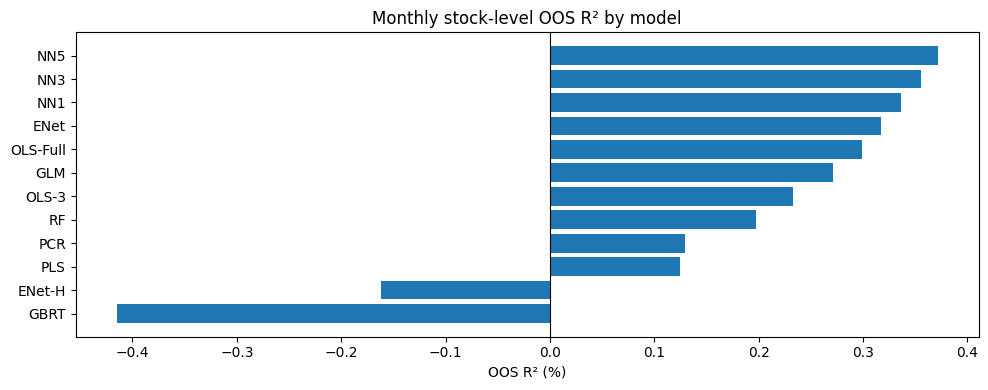

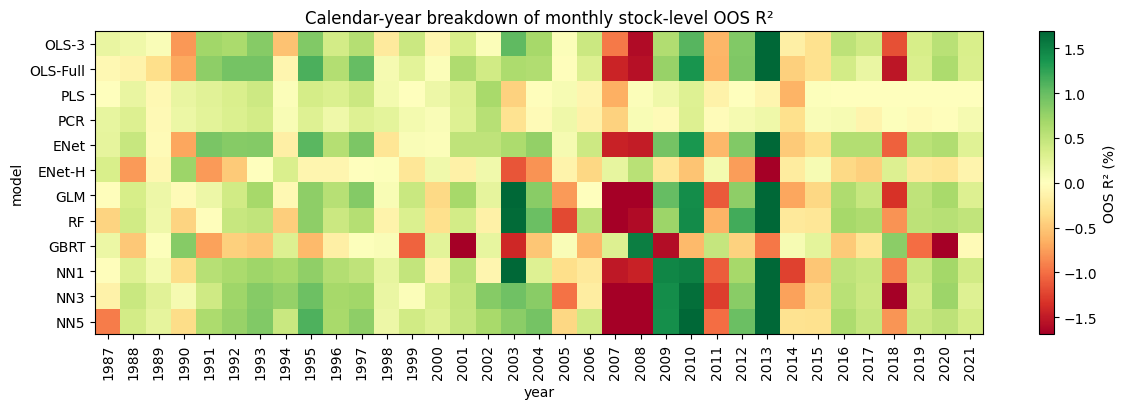

In [7]:
# ====================================================
# Paper Table 1-style stock-level predictive performance
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

MODEL_PLOT_ORDER = [
    "OLS-3", "OLS-Full", "PLS", "PCR", "ENet", "ENet-H",
    "GLM", "RF", "GBRT", "NN1", "NN3", "NN5",
]


def available_model_order(values):
    """Keep paper-like ordering while allowing the notebook to run with any subset of models."""
    values = [str(value) for value in values if pd.notna(value)]
    ordered = [model for model in MODEL_PLOT_ORDER if model in set(values)]
    extras = sorted(model for model in values if model not in set(ordered))
    return ordered + extras


def oos_r2_percent(actual, predicted):
    """Out-of-sample R² relative to the paper's zero-return benchmark forecast."""
    actual = pd.to_numeric(actual, errors="coerce").to_numpy(dtype="float64")
    predicted = pd.to_numeric(predicted, errors="coerce").to_numpy(dtype="float64")
    valid = np.isfinite(actual) & np.isfinite(predicted)
    if valid.sum() == 0:
        return np.nan
    numerator = np.sum((actual[valid] - predicted[valid]) ** 2)
    denominator = np.sum(actual[valid] ** 2)
    if denominator == 0:
        return np.nan
    return 100 * (1 - numerator / denominator)


def stock_r2_by_group(predictions, group_cols):
    """Compute stock-level R² for each group without changing the underlying prediction panel."""
    rows = []
    for keys, group in predictions.groupby(group_cols, observed=True, sort=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["r2_oos_pct"] = oos_r2_percent(group["ret_excess"], group["prediction"])
        row["n_obs"] = len(group)
        rows.append(row)
    return pd.DataFrame(rows)


def plot_heatmap_from_pivot(pivot, title, cmap="RdYlGn"):
    """Plot a compact heatmap from a model-by-column table."""
    if pivot.empty:
        print(f"No data available for {title}.")
        return
    data = pivot.to_numpy(dtype="float64")
    finite = data[np.isfinite(data)]
    if finite.size:
        vmax = np.nanpercentile(np.abs(finite), 95)
        vmax = max(vmax, 0.25)
    else:
        vmax = 1.0
    fig, ax = plt.subplots(figsize=(max(10, 0.35 * pivot.shape[1]), max(4, 0.35 * pivot.shape[0])))
    image = ax.imshow(data, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel(pivot.columns.name or "")
    ax.set_ylabel(pivot.index.name or "")
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=90)
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    fig.colorbar(image, ax=ax, label="OOS R² (%)")
    fig.tight_layout()
    plt.show()


if "stock_predictions" not in globals():
    print("Run Step 18 first so `stock_predictions` exists.")
else:
    required_cols = {"model", "date", "permno", "me", "ret_excess", "prediction"}
    missing_cols = required_cols.difference(stock_predictions.columns)
    if missing_cols:
        raise ValueError(f"stock_predictions is missing required columns: {sorted(missing_cols)}")

    stock_r2_all = stock_r2_by_group(stock_predictions, ["model"])
    stock_r2_all["model"] = pd.Categorical(
        stock_r2_all["model"],
        categories=available_model_order(stock_r2_all["model"]),
        ordered=True,
    )
    stock_r2_all = stock_r2_all.sort_values("model").reset_index(drop=True)

    print("Table 1-style monthly stock-level R², full OOS panel:")
    display(stock_r2_all.round({"r2_oos_pct": 4}))

    # The paper also reports top-1,000 and bottom-1,000 stocks by market value.
    # Because every model shares the same test panel, build those monthly buckets once
    # from a single reference model, then merge the bucket keys into the full panel.
    INCLUDE_TABLE1_SIZE_BUCKETS = True
    if INCLUDE_TABLE1_SIZE_BUCKETS:
        reference_model = available_model_order(stock_predictions["model"].dropna().unique())[0]
        size_source = stock_predictions.loc[
            stock_predictions["model"].eq(reference_model), ["date", "permno", "me"]
        ].dropna(subset=["date", "permno", "me"]).copy()
        size_source["me_rank_desc"] = size_source.groupby("date", observed=True)["me"].rank(
            method="first", ascending=False
        )
        size_source["n_stocks_in_month"] = size_source.groupby("date", observed=True)["permno"].transform("count")

        top_1000_keys = size_source.loc[
            size_source["me_rank_desc"].le(1000), ["date", "permno"]
        ].drop_duplicates()
        bottom_1000_keys = size_source.loc[
            size_source["me_rank_desc"].gt(size_source["n_stocks_in_month"] - 1000), ["date", "permno"]
        ].drop_duplicates()

        sample_frames = [stock_r2_all.assign(sample="All stocks")]
        core_cols = ["model", "date", "permno", "ret_excess", "prediction"]
        for sample_name, keys in [("Top 1,000 by ME", top_1000_keys), ("Bottom 1,000 by ME", bottom_1000_keys)]:
            sample_panel = stock_predictions[core_cols].merge(keys, on=["date", "permno"], how="inner")
            sample_r2 = stock_r2_by_group(sample_panel, ["model"]).assign(sample=sample_name)
            sample_frames.append(sample_r2)
            del sample_panel

        table1_like_r2 = pd.concat(sample_frames, ignore_index=True)
        table1_like_r2["model"] = pd.Categorical(
            table1_like_r2["model"],
            categories=available_model_order(table1_like_r2["model"]),
            ordered=True,
        )
        table1_like_r2 = table1_like_r2.sort_values(["sample", "model"]).reset_index(drop=True)
        table1_like_pivot = table1_like_r2.pivot(index="sample", columns="model", values="r2_oos_pct")

        print("Table 1-style R² by market-equity subsample:")
        display(table1_like_pivot.round(4))

    # This yearly breakdown checks stability of the monthly OOS predictions by calendar year.
    # It is a diagnostic companion to the paper, not the paper's annual-horizon Table 2.
    stock_r2_by_year = stock_predictions.assign(
        year=pd.to_datetime(stock_predictions["date"]).dt.year
    ).pipe(stock_r2_by_group, ["model", "year"])
    stock_r2_by_year["model"] = pd.Categorical(
        stock_r2_by_year["model"],
        categories=available_model_order(stock_r2_by_year["model"]),
        ordered=True,
    )
    annual_stock_r2_pivot = (
        stock_r2_by_year
        .pivot(index="model", columns="year", values="r2_oos_pct")
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    bar_data = stock_r2_all.sort_values("r2_oos_pct", ascending=True)
    ax.barh(bar_data["model"].astype(str), bar_data["r2_oos_pct"])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Monthly stock-level OOS R² by model")
    ax.set_xlabel("OOS R² (%)")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()

    plot_heatmap_from_pivot(
        annual_stock_r2_pivot,
        "Calendar-year breakdown of monthly stock-level OOS R²",
    )


Table 5-style monthly portfolio-level OOS R² for common portfolios:


model,OLS-3,OLS-Full,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
display_name,,,,,,,,,,,,
CMA,1.6360,-3.0447,-3.6460,-0.6310,-0.0655,-0.1039,-4.6730,0.5985,-0.3521,-0.1473,0.0608,1.4170
HML,-3.2558,-3.0796,-1.4282,-0.7185,-1.7131,0.0063,-1.7934,-0.3600,-0.5262,-0.9904,-0.2605,0.3137
RMW,-3.0362,0.8240,0.5893,1.0666,1.6438,0.4777,0.3281,0.3249,1.1158,0.9909,2.0483,2.4367
SMB,-0.4933,-0.9500,0.7645,0.1704,0.8267,-0.6049,0.0131,0.0207,-2.4489,-0.0588,-0.9851,-0.5447
UMD,0.3145,-1.0184,-0.0773,0.0537,-0.3826,0.7773,-0.8712,-0.0945,-1.9175,-1.7389,-0.4304,0.2558


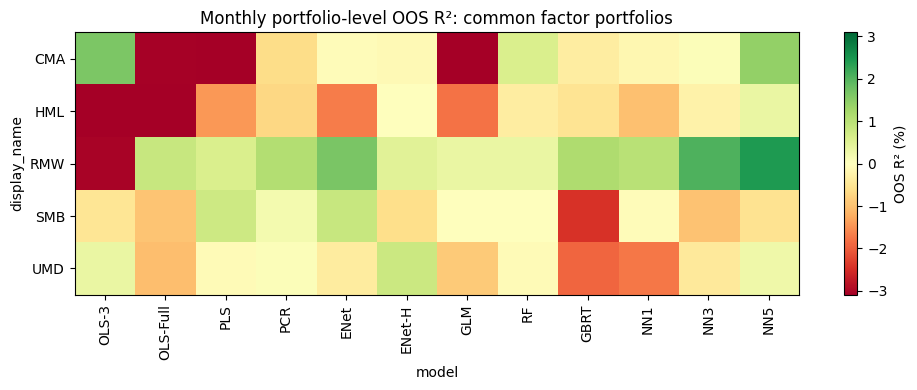

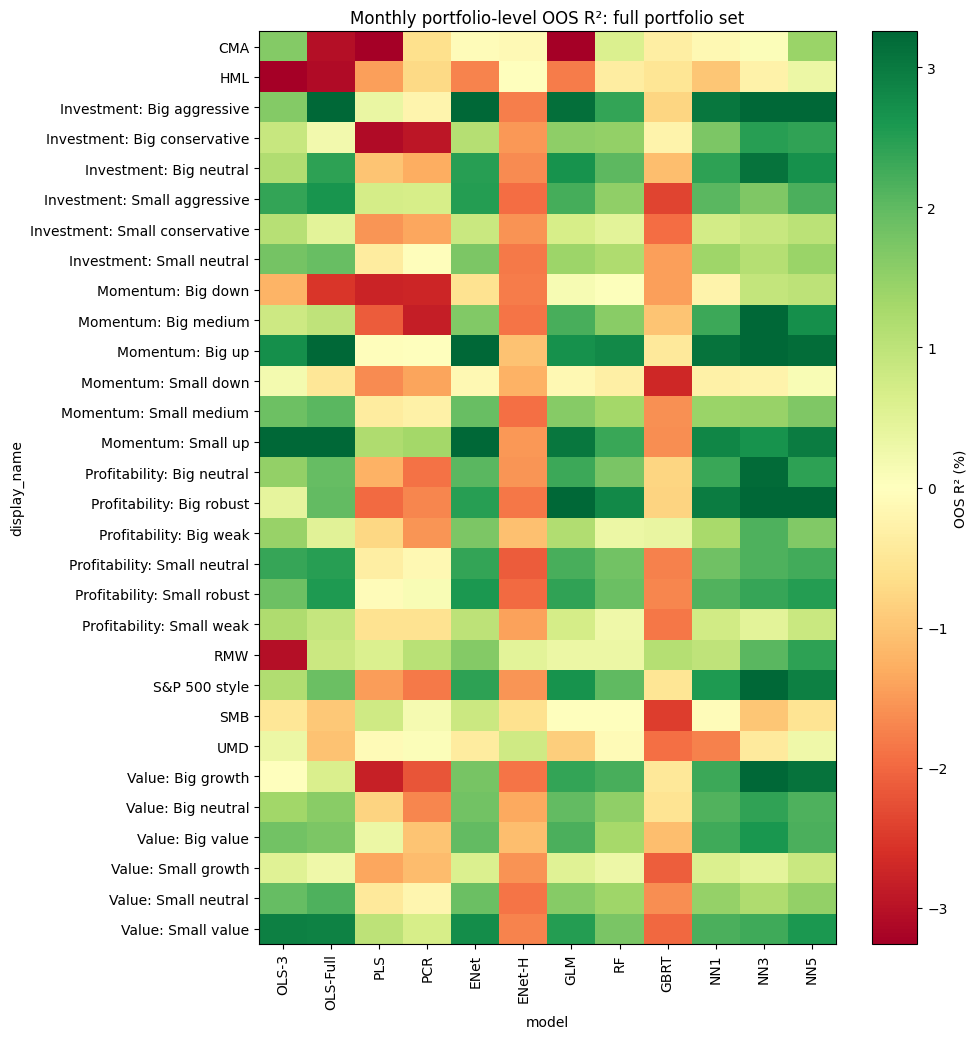

Appendix A.7-style implied annualized Sharpe-ratio gains:


model,OLS-3,OLS-Full,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
display_name,,,,,,,,,,,,
CMA,0.7970,0.7262,0.7166,0.7635,0.7720,0.7714,0.6996,0.7818,0.7677,0.7708,0.7739,0.7938
HML,NaN,NaN,NaN,-0.0488,NaN,0.0003,NaN,-0.0206,-0.0322,NaN,-0.0144,0.0150
RMW,-0.0383,0.0103,0.0074,0.0133,0.0205,0.0060,0.0041,0.0041,0.0139,0.0124,0.0255,0.0303
SMB,-0.0200,-0.0421,0.0265,0.0063,0.0285,-0.0250,0.0005,0.0008,NaN,-0.0022,-0.0440,-0.0223
UMD,0.0050,-0.0165,-0.0012,0.0009,-0.0061,0.0123,-0.0141,-0.0015,-0.0314,-0.0284,-0.0069,0.0041


In [8]:
# ====================================================
# Paper Table 5-style portfolio R² and Appendix A.7-style implied Sharpe gains
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

if "available_model_order" not in globals():
    MODEL_PLOT_ORDER = [
        "OLS-3", "OLS-Full", "PLS", "PCR", "ENet", "ENet-H",
        "GLM", "RF", "GBRT", "NN1", "NN3", "NN5",
    ]

    def available_model_order(values):
        values = [str(value) for value in values if pd.notna(value)]
        ordered = [model for model in MODEL_PLOT_ORDER if model in set(values)]
        extras = sorted(model for model in values if model not in set(ordered))
        return ordered + extras

if "plot_heatmap_from_pivot" not in globals():
    def plot_heatmap_from_pivot(pivot, title, cmap="RdYlGn"):
        data = pivot.to_numpy(dtype="float64")
        finite = data[np.isfinite(data)]
        vmax = max(np.nanpercentile(np.abs(finite), 95), 0.25) if finite.size else 1.0
        fig, ax = plt.subplots(figsize=(max(10, 0.35 * pivot.shape[1]), max(4, 0.35 * pivot.shape[0])))
        image = ax.imshow(data, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks(np.arange(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns, rotation=90)
        ax.set_yticks(np.arange(pivot.shape[0]))
        ax.set_yticklabels(pivot.index)
        fig.colorbar(image, ax=ax, label="OOS R² (%)")
        fig.tight_layout()
        plt.show()


def annualized_sharpe(monthly_returns):
    """Annualized Sharpe ratio from monthly excess returns."""
    returns = pd.to_numeric(monthly_returns, errors="coerce").dropna()
    if len(returns) < 2:
        return np.nan
    sd = returns.std(ddof=1)
    if sd == 0 or not np.isfinite(sd):
        return np.nan
    return np.sqrt(12) * returns.mean() / sd


def implied_sharpe_gain_from_r2(base_sr, r2_oos_pct):
    """Campbell-Thompson-style implied Sharpe gain from predictive R².

    The paper uses this as an economic interpretation of portfolio-level R².
    Negative R² can imply deterioration; values that make the square-root term
    infeasible are returned as NaN instead of forcing a misleading number.
    """
    if not np.isfinite(base_sr) or not np.isfinite(r2_oos_pct):
        return np.nan
    r2 = r2_oos_pct / 100
    if r2 >= 1:
        return np.nan
    inside = (base_sr ** 2 + r2) / (1 - r2)
    if inside < 0:
        return np.nan
    improved_sr = np.sqrt(inside)
    return improved_sr - base_sr


if "portfolio_r2_table" not in globals() or "portfolio_forecasts" not in globals():
    print("Run Step 20 first so `portfolio_r2_table` and `portfolio_forecasts` exist.")
else:
    table5_like_r2 = portfolio_r2_table.copy()
    table5_like_r2["model"] = pd.Categorical(
        table5_like_r2["model"],
        categories=available_model_order(table5_like_r2["model"]),
        ordered=True,
    )

    common_portfolio_ids = [pid for pid in ["MKT", "SMB", "HML", "RMW", "CMA", "UMD"] if pid in set(table5_like_r2["portfolio_id"])]
    table5_common = table5_like_r2.loc[table5_like_r2["portfolio_id"].isin(common_portfolio_ids)].copy()
    table5_common_pivot = table5_common.pivot(index="display_name", columns="model", values="r2_oos_pct")

    print("Table 5-style monthly portfolio-level OOS R² for common portfolios:")
    display(table5_common_pivot.round(4))

    plot_heatmap_from_pivot(
        table5_common_pivot,
        "Monthly portfolio-level OOS R²: common factor portfolios",
    )

    # The full Table 5 also includes 24 long-only 2-by-3 component portfolios.
    # This second heatmap uses whatever Step 20 wrote under the current forecast mode.
    table5_full_pivot = (
        table5_like_r2
        .pivot(index="display_name", columns="model", values="r2_oos_pct")
        .loc[:, [model for model in available_model_order(table5_like_r2["model"].dropna().unique()) if model in table5_like_r2["model"].astype(str).unique()]]
    )
    plot_heatmap_from_pivot(
        table5_full_pivot,
        f"Monthly portfolio-level OOS R²: {PORTFOLIO_FORECAST_MODE} portfolio set",
    )

    # Appendix A.7-style implied Sharpe gains use each portfolio's buy-and-hold Sharpe
    # and the model's R² for that portfolio. This is not the constrained trading strategy
    # in Table 6; it is the analytical economic-magnitude calculation discussed before it.
    base_sr = (
        portfolio_forecasts
        .groupby(["portfolio_id", "display_name"], observed=True)["realized_return"]
        .apply(annualized_sharpe)
        .rename("buy_hold_sr")
        .reset_index()
    )
    implied_sharpe_gain = table5_like_r2.merge(
        base_sr,
        on=["portfolio_id", "display_name"],
        how="left",
    )
    implied_sharpe_gain["implied_sr_gain"] = implied_sharpe_gain.apply(
        lambda row: implied_sharpe_gain_from_r2(row["buy_hold_sr"], row["r2_oos_pct"]),
        axis=1,
    )
    implied_common = implied_sharpe_gain.loc[
        implied_sharpe_gain["portfolio_id"].isin(common_portfolio_ids)
    ].pivot(index="display_name", columns="model", values="implied_sr_gain")

    print("Appendix A.7-style implied annualized Sharpe-ratio gains:")
    display(implied_common.round(4))


Built decile returns for OLS-3: 420 months
Built decile returns for OLS-Full: 420 months
Built decile returns for PLS: 420 months
Built decile returns for PCR: 420 months
Built decile returns for ENet: 420 months
Built decile returns for ENet-H: 420 months
Built decile returns for GLM: 420 months
Built decile returns for RF: 420 months
Built decile returns for GBRT: 420 months
Built decile returns for NN1: 420 months
Built decile returns for NN3: 420 months
Built decile returns for NN5: 420 months
Table 7-style prediction-sorted value-weighted portfolio stats:


,model,decile,Pred_monthly_pct,Avg_monthly_pct,SD_monthly_pct,n_months,SR_annualized
0,OLS-3,1,-0.2701,0.6990,5.3185,420,0.4553
1,OLS-3,2,0.0616,0.7732,4.4524,420,0.6016
2,OLS-3,3,0.2488,0.8103,4.7230,420,0.5943
3,OLS-3,4,0.4066,0.7808,4.7692,420,0.5671
4,OLS-3,5,0.5526,0.8993,4.7742,420,0.6525
...,...,...,...,...,...,...,...
127,NN5,7,0.8054,0.8833,4.6215,420,0.6621
128,NN5,8,0.9097,0.9554,4.8008,420,0.6894
129,NN5,9,1.0604,1.0746,5.1523,420,0.7225
130,NN5,10,1.5924,1.4602,6.5672,420,0.7702


Partial Table 8-style risk diagnostics for the value-weighted 10-minus-1 decile spread:


,model,mean_monthly_pct,sd_monthly_pct,sr_annualized,max_drawdown_pct,worst_1m_return_pct
0,ENet,1.0716,6.2718,0.5919,102.799599,-29.911301
1,ENet-H,0.9855,4.8249,0.7075,122.142998,-24.032301
2,GBRT,1.4210,8.9283,0.5513,138.640503,-45.405602
3,GLM,0.7908,5.3036,0.5165,97.882797,-24.032301
4,NN1,1.4652,5.5969,0.9069,57.091499,-24.916500
5,NN3,1.5014,7.3328,0.7093,129.546005,-42.232399
6,NN5,1.5781,6.8900,0.7934,63.320499,-21.704599
7,OLS-3,0.7403,5.4722,0.4686,107.839302,-17.788500
8,OLS-Full,0.8535,5.0888,0.5810,61.350201,-22.526600
9,PCR,0.6881,5.1726,0.4608,81.451202,-18.407000


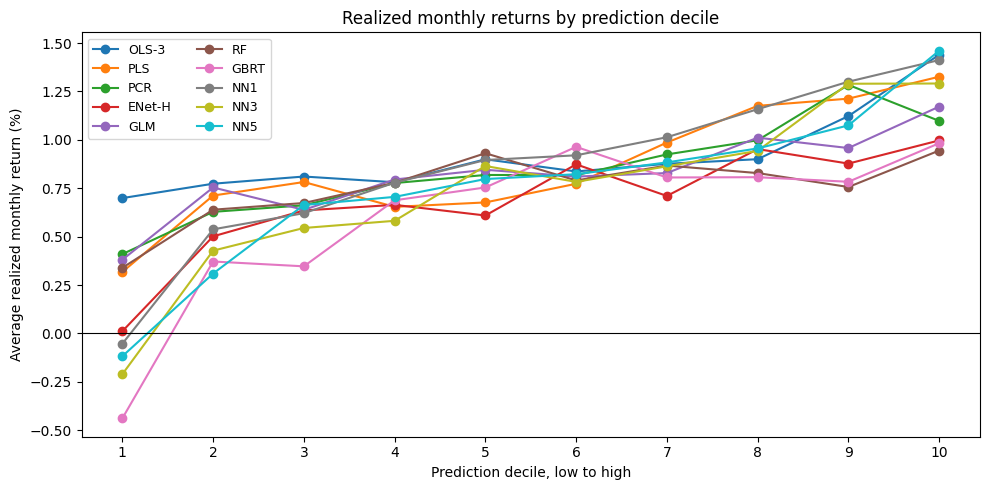

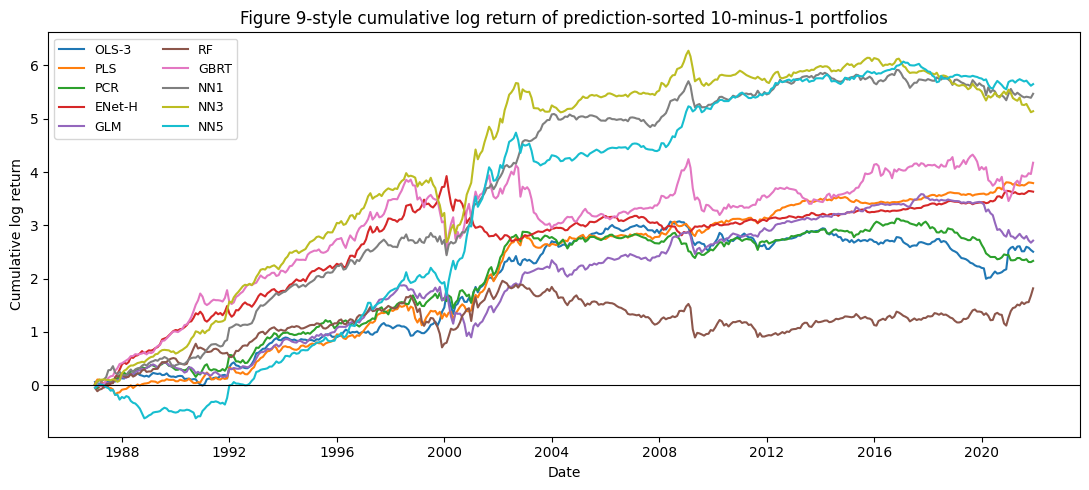

In [9]:
# ====================================================
# Paper Table 7 / Figure 9-style prediction-sorted decile portfolios
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

if "available_model_order" not in globals():
    MODEL_PLOT_ORDER = [
        "OLS-3", "OLS-Full", "PLS", "PCR", "ENet", "ENet-H",
        "GLM", "RF", "GBRT", "NN1", "NN3", "NN5",
    ]

    def available_model_order(values):
        values = [str(value) for value in values if pd.notna(value)]
        ordered = [model for model in MODEL_PLOT_ORDER if model in set(values)]
        extras = sorted(model for model in values if model not in set(ordered))
        return ordered + extras

# This cell is heavier than the R² cells because it sorts millions of stock-month forecasts.
# Keep it True to build all available model decile portfolios, or replace the list below with
# a smaller subset such as ["NN3", "GBRT", "RF"] while iterating.
RUN_PREDICTION_DECILE_PORTFOLIOS = True
DECILE_MODELS_TO_RUN = None  # None means every model in stock_predictions, in paper-like order.
FIGURE9_MODELS_TO_PLOT = ["OLS-3", "PLS", "PCR", "ENet-H", "GLM", "RF", "GBRT", "NN1", "NN3", "NN5"]


def build_prediction_decile_returns(predictions, model_names=None, n_deciles=10, weight_col="weight_me"):
    """Sort stocks into forecast deciles each month and compute value-weighted returns.

    The paper forms deciles from one-month-ahead OOS stock predictions, then uses
    ex ante market-equity weights inside each decile. The `weight_me` column was built
    in Step 18 from prior-month CRSP market equity, so the weights are known before
    the realized return month.
    """
    required_cols = {"model", "date", "permno", "prediction", "ret_excess", weight_col}
    missing_cols = required_cols.difference(predictions.columns)
    if missing_cols:
        raise ValueError(f"stock_predictions is missing required columns: {sorted(missing_cols)}")

    if model_names is None:
        model_names = available_model_order(predictions["model"].dropna().unique())
    else:
        model_names = [model for model in model_names if model in set(predictions["model"].astype(str).unique())]

    monthly_frames = []
    cols = ["model", "date", "permno", "prediction", "ret_excess", weight_col]

    for model_name in model_names:
        model_panel = predictions.loc[predictions["model"].astype(str).eq(model_name), cols].copy()
        model_panel = model_panel.dropna(subset=["date", "prediction", "ret_excess", weight_col])
        model_panel = model_panel.loc[model_panel[weight_col].gt(0)].copy()
        if model_panel.empty:
            print(f"Skipping {model_name}: no usable rows after removing missing weights/returns.")
            continue

        # Rank forecasts within each month. Converting ranks into integer buckets gives
        # qcut-like equal-count deciles without the duplicate-edge problems that happen
        # when many stocks share very similar forecasts.
        model_panel["forecast_rank"] = model_panel.groupby("date", observed=True)["prediction"].rank(method="first")
        model_panel["n_in_month"] = model_panel.groupby("date", observed=True)["prediction"].transform("count")
        model_panel = model_panel.loc[model_panel["n_in_month"].ge(n_deciles)].copy()
        model_panel["decile"] = (
            np.floor((model_panel["forecast_rank"] - 1) * n_deciles / model_panel["n_in_month"]).astype("int16") + 1
        )

        model_panel["weighted_prediction_sum"] = model_panel["prediction"] * model_panel[weight_col]
        model_panel["weighted_return_sum"] = model_panel["ret_excess"] * model_panel[weight_col]

        monthly = (
            model_panel
            .groupby(["model", "date", "decile"], observed=True)
            .agg(
                weight_sum=(weight_col, "sum"),
                predicted_weighted_sum=("weighted_prediction_sum", "sum"),
                realized_weighted_sum=("weighted_return_sum", "sum"),
                n_stocks=("permno", "nunique"),
            )
            .reset_index()
        )
        monthly["predicted_return"] = monthly["predicted_weighted_sum"] / monthly["weight_sum"]
        monthly["realized_return"] = monthly["realized_weighted_sum"] / monthly["weight_sum"]
        monthly_frames.append(monthly[["model", "date", "decile", "predicted_return", "realized_return", "n_stocks", "weight_sum"]])
        print(f"Built decile returns for {model_name}: {monthly['date'].nunique()} months")

    if not monthly_frames:
        return pd.DataFrame(columns=["model", "date", "decile", "predicted_return", "realized_return", "n_stocks", "weight_sum"])
    return pd.concat(monthly_frames, ignore_index=True)


def summarize_prediction_deciles(decile_monthly):
    """Create the Table 7-style Pred / Avg / SD / Sharpe summary."""
    decile_stats = (
        decile_monthly
        .groupby(["model", "decile"], observed=True)
        .agg(
            Pred_monthly_pct=("predicted_return", lambda x: 100 * x.mean()),
            Avg_monthly_pct=("realized_return", lambda x: 100 * x.mean()),
            SD_monthly_pct=("realized_return", lambda x: 100 * x.std(ddof=1)),
            n_months=("realized_return", "count"),
        )
        .reset_index()
    )
    decile_stats["SR_annualized"] = np.sqrt(12) * (
        decile_stats["Avg_monthly_pct"] / decile_stats["SD_monthly_pct"]
    )

    low = decile_monthly.loc[decile_monthly["decile"].eq(1), ["model", "date", "predicted_return", "realized_return"]]
    high = decile_monthly.loc[decile_monthly["decile"].eq(10), ["model", "date", "predicted_return", "realized_return"]]
    spread = high.merge(low, on=["model", "date"], suffixes=("_high", "_low"))
    spread["decile"] = "H-L"
    spread["predicted_return"] = spread["predicted_return_high"] - spread["predicted_return_low"]
    spread["realized_return"] = spread["realized_return_high"] - spread["realized_return_low"]

    spread_stats = (
        spread
        .groupby(["model", "decile"], observed=True)
        .agg(
            Pred_monthly_pct=("predicted_return", lambda x: 100 * x.mean()),
            Avg_monthly_pct=("realized_return", lambda x: 100 * x.mean()),
            SD_monthly_pct=("realized_return", lambda x: 100 * x.std(ddof=1)),
            n_months=("realized_return", "count"),
        )
        .reset_index()
    )
    spread_stats["SR_annualized"] = np.sqrt(12) * (
        spread_stats["Avg_monthly_pct"] / spread_stats["SD_monthly_pct"]
    )
    return pd.concat([decile_stats, spread_stats], ignore_index=True), spread


def max_drawdown_pct(monthly_returns):
    """Maximum drawdown from cumulative log returns, matching the paper's definition."""
    returns = pd.to_numeric(monthly_returns, errors="coerce").dropna().clip(lower=-0.99)
    if returns.empty:
        return np.nan
    cumulative_log_return = np.log1p(returns).cumsum()
    drawdown = cumulative_log_return.cummax() - cumulative_log_return
    return 100 * drawdown.max()


if "stock_predictions" not in globals():
    print("Run Step 18 first so `stock_predictions` exists.")
elif not RUN_PREDICTION_DECILE_PORTFOLIOS:
    print("Set RUN_PREDICTION_DECILE_PORTFOLIOS = True when you want to build decile portfolios.")
else:
    if DECILE_MODELS_TO_RUN is None:
        DECILE_MODELS_TO_RUN = available_model_order(stock_predictions["model"].dropna().unique())

    decile_monthly_returns = build_prediction_decile_returns(
        stock_predictions,
        model_names=DECILE_MODELS_TO_RUN,
        n_deciles=10,
        weight_col="weight_me",
    )
    decile_portfolio_stats, decile_spread_monthly = summarize_prediction_deciles(decile_monthly_returns)
    decile_portfolio_stats["model"] = pd.Categorical(
        decile_portfolio_stats["model"],
        categories=available_model_order(decile_portfolio_stats["model"].dropna().unique()),
        ordered=True,
    )
    decile_portfolio_stats["decile_order"] = decile_portfolio_stats["decile"].apply(
        lambda value: 11 if str(value) == "H-L" else int(value)
    )
    decile_portfolio_stats = (
        decile_portfolio_stats
        .sort_values(["model", "decile_order"])
        .drop(columns="decile_order")
        .reset_index(drop=True)
    )

    print("Table 7-style prediction-sorted value-weighted portfolio stats:")
    display(decile_portfolio_stats.round({
        "Pred_monthly_pct": 4,
        "Avg_monthly_pct": 4,
        "SD_monthly_pct": 4,
        "SR_annualized": 4,
    }))

    spread_risk_summary = (
        decile_spread_monthly
        .groupby("model", observed=True)
        .agg(
            mean_monthly_pct=("realized_return", lambda x: 100 * x.mean()),
            sd_monthly_pct=("realized_return", lambda x: 100 * x.std(ddof=1)),
            sr_annualized=("realized_return", annualized_sharpe),
            max_drawdown_pct=("realized_return", max_drawdown_pct),
            worst_1m_return_pct=("realized_return", lambda x: 100 * x.min()),
        )
        .reset_index()
    )
    print("Partial Table 8-style risk diagnostics for the value-weighted 10-minus-1 decile spread:")
    display(spread_risk_summary.round(4))

    selected_for_plot = [model for model in FIGURE9_MODELS_TO_PLOT if model in set(decile_portfolio_stats["model"].astype(str))]
    decile_only = decile_portfolio_stats.loc[decile_portfolio_stats["decile"].ne("H-L")].copy()
    decile_only["decile"] = decile_only["decile"].astype(int)

    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name in selected_for_plot:
        model_stats = decile_only.loc[decile_only["model"].astype(str).eq(model_name)].sort_values("decile")
        ax.plot(model_stats["decile"], model_stats["Avg_monthly_pct"], marker="o", label=model_name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Realized monthly returns by prediction decile")
    ax.set_xlabel("Prediction decile, low to high")
    ax.set_ylabel("Average realized monthly return (%)")
    ax.set_xticks(range(1, 11))
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    for model_name in selected_for_plot:
        model_spread = decile_spread_monthly.loc[
            decile_spread_monthly["model"].astype(str).eq(model_name)
        ].sort_values("date")
        cumulative = np.log1p(model_spread["realized_return"].clip(lower=-0.99)).cumsum()
        ax.plot(model_spread["date"], cumulative, label=model_name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Figure 9-style cumulative log return of prediction-sorted 10-minus-1 portfolios")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative log return")
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    plt.show()


Available Figure 3-style model complexity diagnostics:


,test_year,value,model,metric
0,1987,4.0,ENet,Selected features
1,1988,17.0,ENet,Selected features
2,1989,30.0,ENet,Selected features
3,1990,26.0,ENet,Selected features
4,1991,23.0,ENet,Selected features
5,1992,29.0,ENet,Selected features
6,1993,6.0,ENet,Selected features
7,1994,49.0,ENet,Selected features
8,1995,50.0,ENet,Selected features
9,1996,50.0,ENet,Selected features


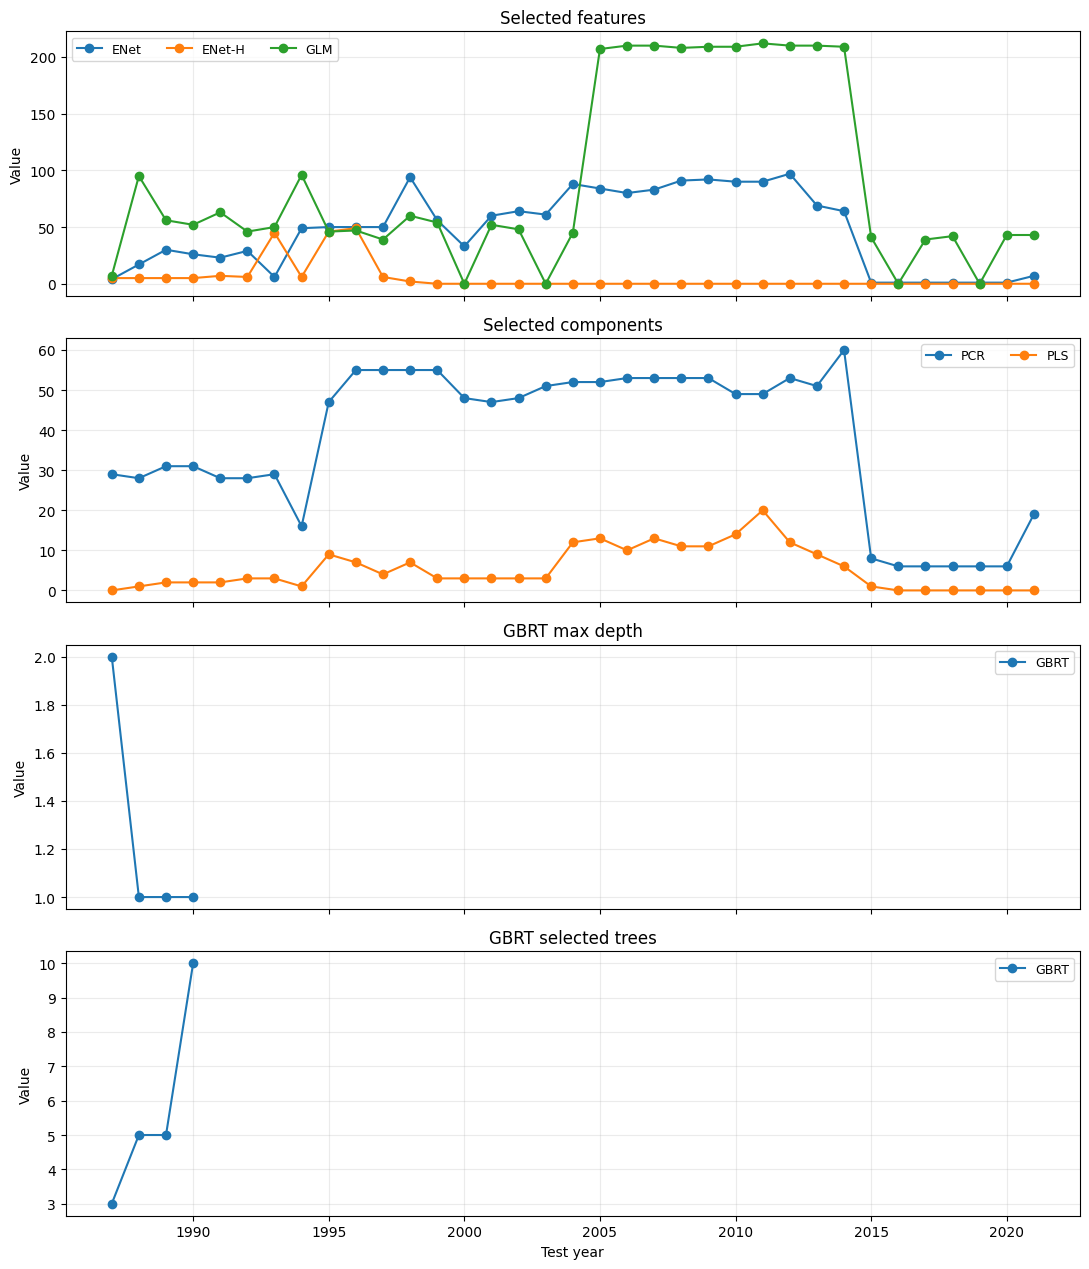

PCR/PLS annual-horizon R² file found. This is Table 2-style, but only for PCR and PLS:


,year,model,r2_oos_pct,n_obs
0,1987,pcr,0.444703,67061
1,1988,pcr,-0.301064,66297
2,1989,pcr,-0.554243,64184
3,1990,pcr,-0.312126,63458
4,1991,pcr,0.000000,62122


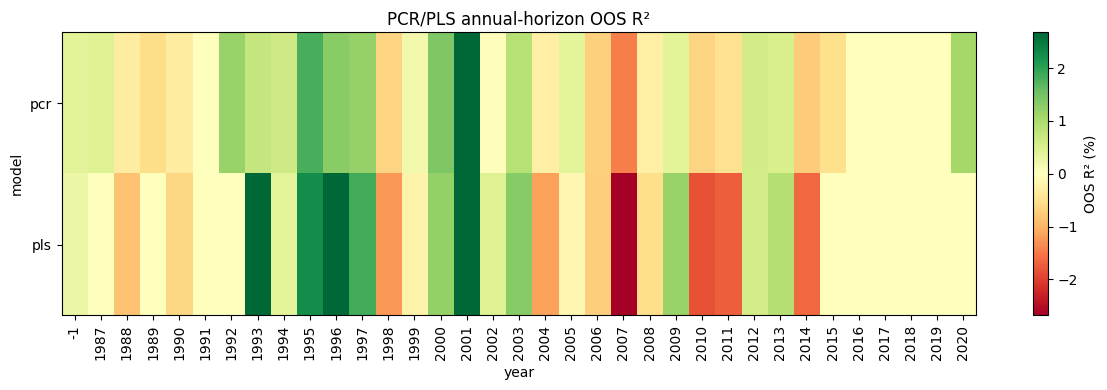

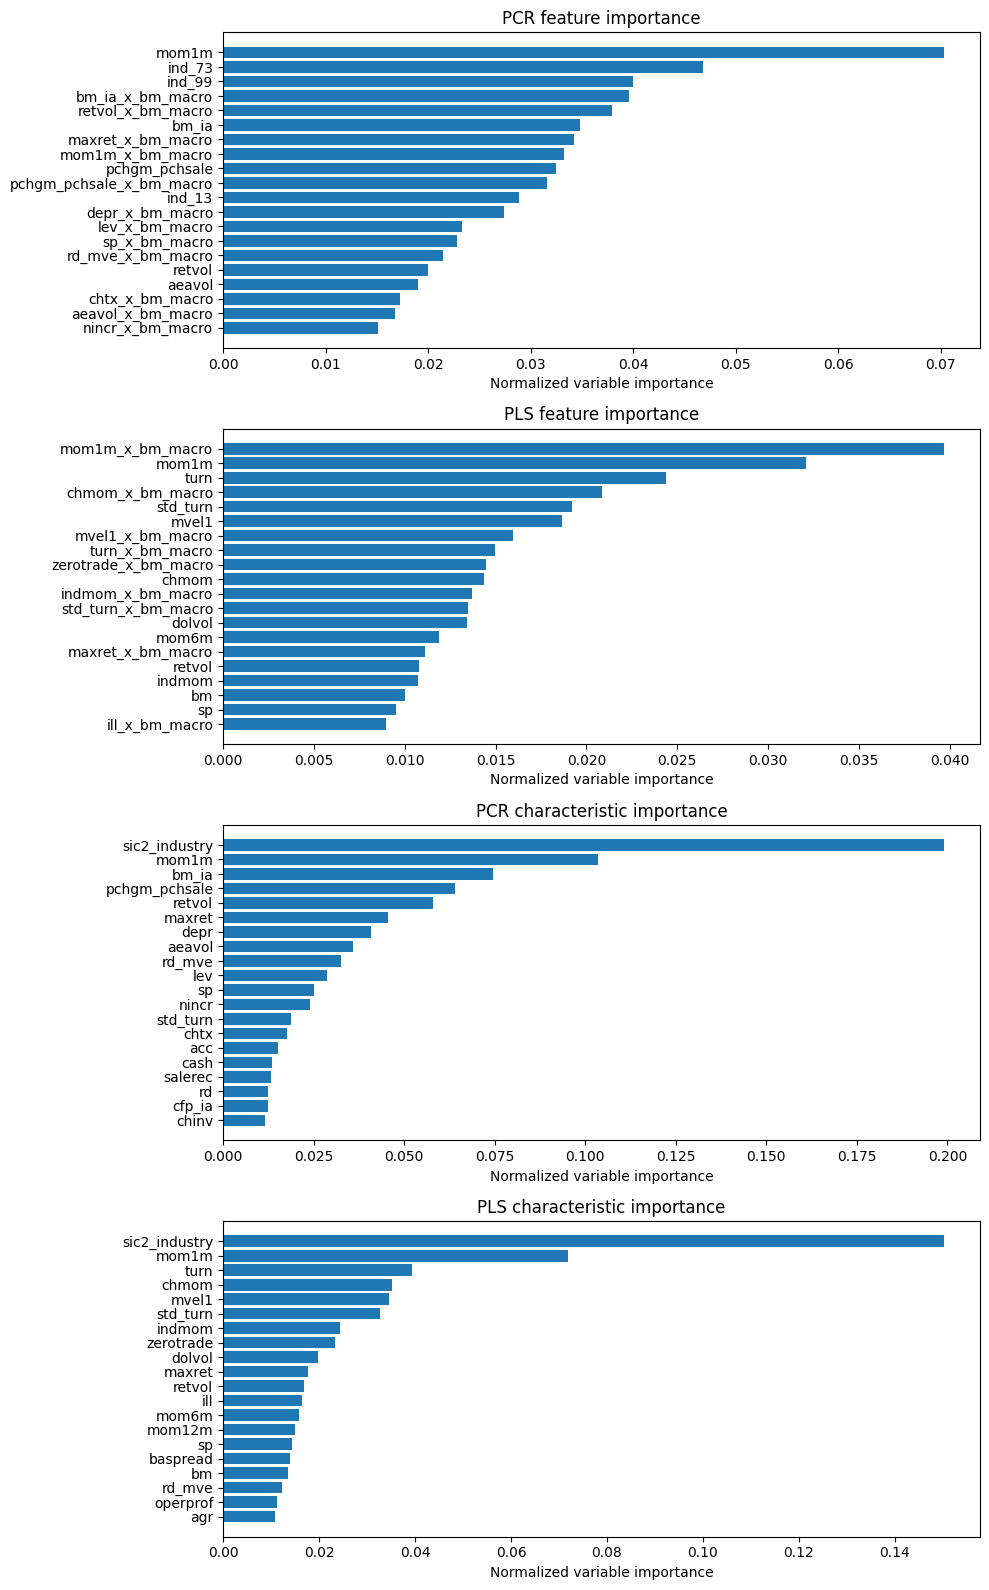

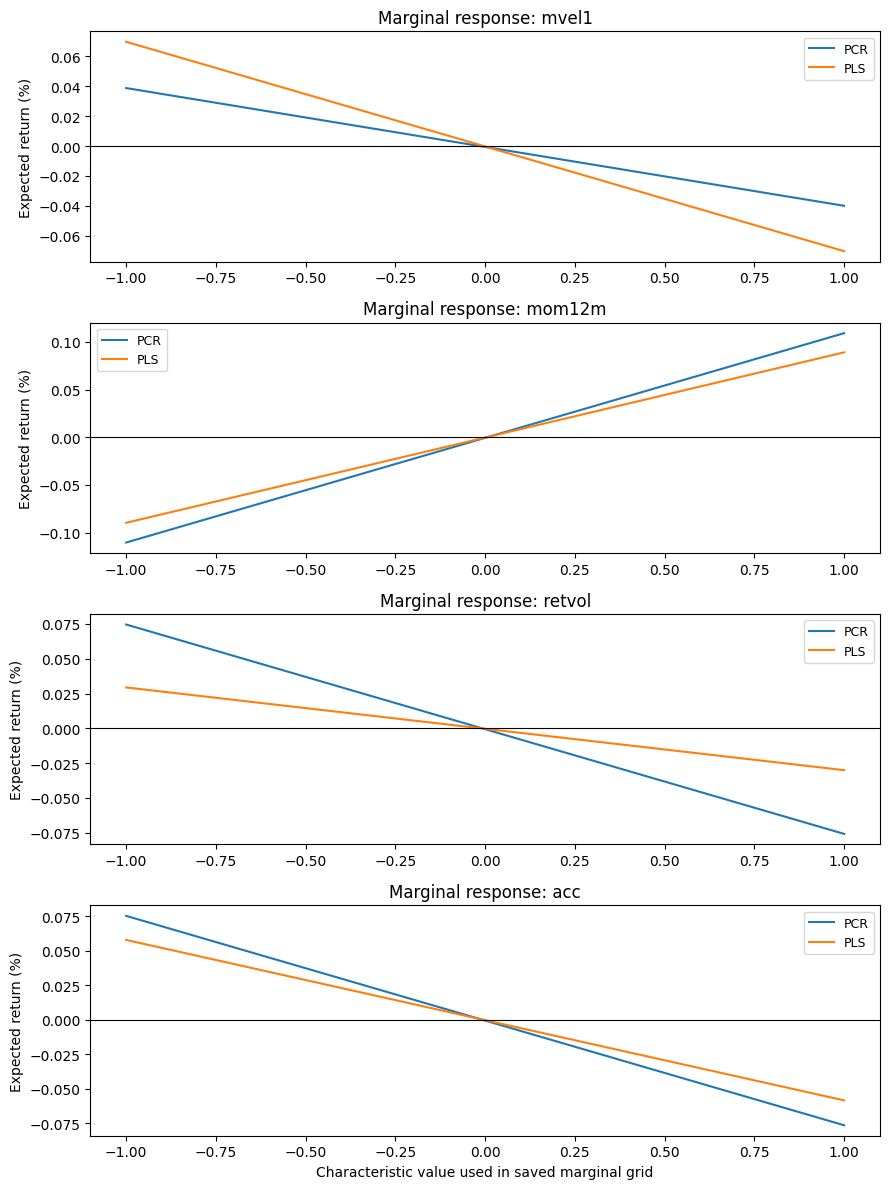

In [10]:
# ====================================================
# Paper Figure 3-style complexity, PCR/PLS annual horizon, and saved importance plots
# ====================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

if "plot_heatmap_from_pivot" not in globals():
    def plot_heatmap_from_pivot(pivot, title, cmap="RdYlGn"):
        data = pivot.to_numpy(dtype="float64")
        finite = data[np.isfinite(data)]
        vmax = max(np.nanpercentile(np.abs(finite), 95), 0.25) if finite.size else 1.0
        fig, ax = plt.subplots(figsize=(max(10, 0.35 * pivot.shape[1]), max(4, 0.35 * pivot.shape[0])))
        image = ax.imshow(data, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks(np.arange(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns, rotation=90)
        ax.set_yticks(np.arange(pivot.shape[0]))
        ax.set_yticklabels(pivot.index)
        fig.colorbar(image, ax=ax, label="OOS R² (%)")
        fig.tight_layout()
        plt.show()

PROJECT_ROOT = globals().get("PROJECT_ROOT", Path("/Users/julianreynolds/Project"))
RESULTS_DIR = globals().get("RESULTS_DIR", PROJECT_ROOT / "data" / "Results")
PCR_PLS_DIR = RESULTS_DIR / "pcr_pls"
FML_DIR = RESULTS_DIR / "fml_ols_enet_results"
GLM_DIR = RESULTS_DIR / "glm_3"
TREE_DIR = RESULTS_DIR / "tree_results"

complexity_frames = []


def add_parquet_complexity(path, model_label, value_col, metric_label):
    """Summarize repeated stock-level diagnostic columns into one value per test year."""
    path = Path(path)
    if not path.exists():
        return
    df = pd.read_parquet(path, columns=["test_year", value_col])
    yearly = (
        df.dropna(subset=["test_year", value_col])
        .groupby("test_year", observed=True)[value_col]
        .median()
        .reset_index(name="value")
    )
    yearly["model"] = model_label
    yearly["metric"] = metric_label
    complexity_frames.append(yearly)


# ENet and GLM files contain the number of selected/active features in the saved predictions.
add_parquet_complexity(
    FML_DIR / "FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet",
    "ENet",
    "n_nonzero_features",
    "Selected features",
)
add_parquet_complexity(
    FML_DIR / "FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet",
    "ENet-H",
    "n_nonzero_features",
    "Selected features",
)
add_parquet_complexity(
    GLM_DIR / "glm_3_stock_level_oos_predictions_with_ids.parquet",
    "GLM",
    "active_features",
    "Selected features",
)

# PCR/PLS yearly summaries contain the selected number of components.
for model_label, file_name in [("PCR", "pcr_yearly_summary.csv"), ("PLS", "pls_yearly_summary.csv")]:
    path = PCR_PLS_DIR / file_name
    if path.exists():
        yearly = pd.read_csv(path, usecols=["test_year", "best_k"])
        yearly = yearly.rename(columns={"best_k": "value"})
        yearly["model"] = model_label
        yearly["metric"] = "Selected components"
        complexity_frames.append(yearly)

# The downloaded tree diagnostics do not include RF average tree depth or GBRT distinct-characteristic counts.
# They do include GBRT depth and selected number of boosting trees, so we plot those as available complexity proxies.
gbrt_diag_path = TREE_DIR / "gbrt_test_diagnostics.csv"
if gbrt_diag_path.exists():
    gbrt_diag = pd.read_csv(gbrt_diag_path)
    for value_col, metric_label in [
        ("max_depth", "GBRT max depth"),
        ("selected_n_estimators", "GBRT selected trees"),
    ]:
        if value_col in gbrt_diag.columns:
            yearly = gbrt_diag[["test_year", value_col]].rename(columns={value_col: "value"}).copy()
            yearly["model"] = "GBRT"
            yearly["metric"] = metric_label
            complexity_frames.append(yearly)

if complexity_frames:
    complexity_table = pd.concat(complexity_frames, ignore_index=True)
    print("Available Figure 3-style model complexity diagnostics:")
    display(complexity_table.head(20))

    metrics = list(complexity_table["metric"].drop_duplicates())
    fig, axes = plt.subplots(len(metrics), 1, figsize=(11, 3.2 * len(metrics)), sharex=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        metric_data = complexity_table.loc[complexity_table["metric"].eq(metric)]
        for model_name, model_data in metric_data.groupby("model", observed=True):
            model_data = model_data.sort_values("test_year")
            ax.plot(model_data["test_year"], model_data["value"], marker="o", linewidth=1.5, label=model_name)
        ax.set_title(metric)
        ax.set_ylabel("Value")
        ax.grid(alpha=0.25)
        ax.legend(ncol=3, fontsize=9)
    axes[-1].set_xlabel("Test year")
    fig.tight_layout()
    plt.show()
else:
    print("No saved complexity diagnostics found in the Results folder.")

# The only annual-horizon Table 2-style file currently present is PCR/PLS.
annual_horizon_path = PCR_PLS_DIR / "table2_annual_r2_12m_ahead.csv"
if annual_horizon_path.exists():
    pcr_pls_annual_horizon_r2 = pd.read_csv(annual_horizon_path)
    print("PCR/PLS annual-horizon R² file found. This is Table 2-style, but only for PCR and PLS:")
    display(pcr_pls_annual_horizon_r2.head())

    pivot = pcr_pls_annual_horizon_r2.pivot(index="model", columns="year", values="r2_oos_pct")
    plot_heatmap_from_pivot(pivot, "PCR/PLS annual-horizon OOS R²")

# Saved PCR/PLS variable-importance files let us recreate a subset of the paper's importance analysis.
importance_specs = [
    ("PCR feature importance", PCR_PLS_DIR / "pcr_variable_importance.csv", "feature", "vi_normalized"),
    ("PLS feature importance", PCR_PLS_DIR / "pls_variable_importance.csv", "feature", "vi_normalized"),
    ("PCR characteristic importance", PCR_PLS_DIR / "pcr_char_importance.csv", "char", "vi_normalized_char"),
    ("PLS characteristic importance", PCR_PLS_DIR / "pls_char_importance.csv", "char", "vi_normalized_char"),
]
existing_importance = [spec for spec in importance_specs if spec[1].exists()]
if existing_importance:
    fig, axes = plt.subplots(len(existing_importance), 1, figsize=(10, 4 * len(existing_importance)))
    if len(existing_importance) == 1:
        axes = [axes]
    for ax, (title, path, label_col, value_col) in zip(axes, existing_importance):
        df = pd.read_csv(path)
        top = df.dropna(subset=[label_col, value_col]).nlargest(20, value_col).sort_values(value_col)
        ax.barh(top[label_col], top[value_col])
        ax.set_title(title)
        ax.set_xlabel("Normalized variable importance")
    fig.tight_layout()
    plt.show()
else:
    print("No PCR/PLS variable-importance files found.")

# PCR/PLS marginal-response files are also available. These are useful for paper-style
# marginal relationship plots, but only for the characteristics saved by those notebooks.
marginal_frames = []
for model_label, file_name in [("PCR", "marginals_pcr.csv"), ("PLS", "marginals_pls.csv")]:
    path = PCR_PLS_DIR / file_name
    if path.exists():
        marginal_frames.append(pd.read_csv(path).assign(model=model_label))

if marginal_frames:
    pcr_pls_marginals = pd.concat(marginal_frames, ignore_index=True)
    chars_to_plot = list(pcr_pls_marginals["char"].drop_duplicates()[:6])
    fig, axes = plt.subplots(len(chars_to_plot), 1, figsize=(9, 3.0 * len(chars_to_plot)), sharex=False)
    if len(chars_to_plot) == 1:
        axes = [axes]
    for ax, char_name in zip(axes, chars_to_plot):
        char_data = pcr_pls_marginals.loc[pcr_pls_marginals["char"].eq(char_name)]
        for model_name, model_data in char_data.groupby("model", observed=True):
            model_data = model_data.sort_values("x_value")
            ax.plot(model_data["x_value"], 100 * model_data["expected_return"], label=model_name)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"Marginal response: {char_name}")
        ax.set_ylabel("Expected return (%)")
        ax.legend(fontsize=9)
    axes[-1].set_xlabel("Characteristic value used in saved marginal grid")
    fig.tight_layout()
    plt.show()
else:
    print("No PCR/PLS marginal-response files found.")
